# ACV - Privacy vs Utility · Single Video Analysis



## Core terms (including disparity)

Let:
- $A_{body}$ = person bounding-box area
- $A_{head}$ = head bounding-box area
- $A_{img}$ = image area
- $D(x,y)$ = normalized disparity map value at pixel $(x,y)$ — output of Depth Anything V2, where $1$ is near and $0$ is far
- $\Omega_{head}$ = pixels inside the detected head box

Head disparity is defined as:
$$
d = \operatorname{median}_{(x,y)\in\Omega_{head}} D(x,y)
$$

So:
- $d\approx 1$ means the head is near the camera (higher privacy risk)
- $d\approx 0$ means the head is far from the camera (lower privacy risk)

Note: Depth Anything V2 outputs inverse depth (disparity), so closer objects have higher raw values. No inversion is applied — the model output is used directly after min-max normalisation to $[0,1]$.

All equations below use this same $d$ definition wherever disparity appears.

---

## Equations used in the benchmark

1. `fullbbox` (area-based, alpha-calibrated)
$$
r = \max\left(\alpha_{full}\,\ln\left(100\cdot\frac{A_{body}}{A_{img}}\right),\ 1\right)
$$
Explanation: larger person area in frame gives larger $r$.

2. `headbbox` (head-area-based, alpha-calibrated)
$$
r = \max\left(\alpha_{head}\,\ln\left(5000\cdot\frac{A_{head}}{A_{img}}\right),\ 1\right)
$$
Explanation: larger visible head area gives larger $r$.

3. `pure_head_depth` (disparity-based, alpha-calibrated)
$$
r = \max\left(\alpha_{depth}\,\ln\left(1 + 99d\right),\ 1\right)
$$
Explanation: nearer heads (higher $d$) produce stronger redaction.

4. `live_no_alpha` (disparity-based, no calibrated alpha by design)
For blur/pixelate modes:
$$
r = 1 + (R_{max,mode} - 1)\cdot d
$$
Explanation: $r$ scales linearly from $1$ to $R_{max,mode}$ as disparity increases.

For blackout/depth-zone policy:
- `blackout`: direct black mask (binary action, no $r$ scaling).
- `depthzone`: if $d > T_{high}$ => blackout; else if $d > T_{medium}$ => fixed pixelate; else fixed blur.

For equations 1-3, calibrated alpha values from the calibration cell are used for scoring.


### Cell 0 Summary
Configure dataset path, runtime redaction thresholds, evaluation equations, and alpha values used across the notebook.

In [10]:
# CELL 0 · CONFIG — edit only this cell for runs

OUT_DIR      = "output"
# VIDEO_PATH   = "PEViD-HD/droppingBag_day_indoor_1_1.mpg"
VIDEO_PATH = "PEViD-HD/validation_video_1.mp4"

MAX_FRAMES   = None
SAMPLE_EVERY = 3
REID_EVERY   = 10
DEPTH_SAMPLE_EVERY = 3
YOLO_CONF    = 0.25
HEAD_FRAC    = 0.30
SMOOTH_WIN   = 5
GAMMA        = 3.5

# no-alpha equation controls (used by equation: live_no_alpha)
R_MAX_CONFIG = {"blur": 35, "pixelate": 20}
DEPTH_ZONE_THRESH = {"high": 0.70, "medium": 0.30}
DEPTH_ZONE_FIXED_R = {"medium": 15.0, "low": 9.0}

# unified benchmark setup
EQUATIONS = ["fullbbox", "headbbox", "pure_head_depth", "live_no_alpha"]
MODES     = ["blur", "pixelate", "blackout", "depthzone"]

# alpha is used by the first 3 equations; calibration cell updates these values
# EVAL_ALPHA = {
#     "fullbbox": 1.0,
#     "headbbox": 1.0,
#     "pure_head_depth": 1.0,
# }

EVAL_ALPHA = {
    'fullbbox': 1.0,
    'headbbox': 0.484202,
    'pure_head_depth': 0.335052,
}

print("Using equations:", EQUATIONS)
print("Using modes:", MODES)
print("R_MAX_CONFIG:", R_MAX_CONFIG)
print("Eval alphas:", EVAL_ALPHA)

Using equations: ['fullbbox', 'headbbox', 'pure_head_depth', 'live_no_alpha']
Using modes: ['blur', 'pixelate', 'blackout', 'depthzone']
R_MAX_CONFIG: {'blur': 35, 'pixelate': 20}
Eval alphas: {'fullbbox': 1.0, 'headbbox': 0.484202, 'pure_head_depth': 0.335052}


### Cell 1 Summary
Install all required Python packages for detection, depth estimation, plotting, and benchmarking.

In [11]:
# CELL 1 · INSTALL
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
    "ultralytics", "opencv-python-headless", "matplotlib",
    "pandas", "numpy", "torch", "torchvision", "Pillow",
    "transformers", "accelerate"], check=True)
print("OK")

OK


### Cell 2 Summary
Load libraries, initialize YOLO and Depth Anything models, and prepare the ReID feature extractor.

In [12]:
# CELL 2 · IMPORTS + MODELS
import cv2, numpy as np, torch, warnings
import torch.nn.functional as F
from pathlib import Path
from PIL import Image as PILImage
from torchvision import models, transforms
from ultralytics import YOLO
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams["figure.dpi"] = 110
warnings.filterwarnings("ignore")
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

yolo_seg  = YOLO("yolov8n-seg.pt")   # person segmentation masks
yolo_pose = YOLO("yolov8n-pose.pt")  # keypoint detection
yolo_det  = YOLO("yolov8n.pt")       # privacy detection confidence

# ResNet50 as lightweight ReID backbone (no OSNet dependency)
_bb = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
_bb.fc = torch.nn.Identity()
reid_model = _bb.eval().to(DEVICE)
reid_tf = transforms.Compose([
    transforms.Resize((256, 128)), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
# ── Depth Anything V2 Small ──────────────────────────────────────────────────
_DA_ID = "depth-anything/Depth-Anything-V2-Small-hf"
depth_processor = AutoImageProcessor.from_pretrained(_DA_ID)
depth_model_da  = AutoModelForDepthEstimation.from_pretrained(_DA_ID).to(DEVICE).eval()
print("Models ready.")

Device: cuda


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

Models ready.


### Cell 3 Summary
Define person/accessory detection, strict head-depth disparity extraction, benchmark r equations, and live redaction logic.

In [13]:
# CELL 3 · HELPERS — run once

from collections import Counter

# ── detection ──────────────────────────────────────────────────────────────────
def _fallback_head_box(box, H, W):
    x1, y1, x2, y2 = [float(v) for v in box]
    y2h = min(float(H), y1 + HEAD_FRAC * max(y2 - y1, 1.0))
    return [max(0.0, x1), max(0.0, y1), min(float(W), x2), max(y1 + 1.0, y2h)]

def _box_iou(a, b):
    ax1, ay1, ax2, ay2 = [float(v) for v in a]
    bx1, by1, bx2, by2 = [float(v) for v in b]
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

def _head_box_from_pose(kps, person_box, H, W):
    x1, y1, x2, y2 = [float(v) for v in person_box]
    vis = kps[:, 2] > 0.3
    head_ids = [0, 1, 2, 3, 4]
    pts = np.array([kps[i, :2] for i in head_ids if vis[i]], dtype=float)
    if len(pts) < 2:
        return None

    person_w = max(x2 - x1, 1.0)
    person_h = max(y2 - y1, 1.0)
    shoulder_w = (float(np.linalg.norm(kps[5, :2] - kps[6, :2]))
                  if vis[5] and vis[6] else 0.35 * person_w)
    pad_x = max(0.12 * person_w, 0.30 * shoulder_w)
    pad_top = max(0.10 * person_h, 0.25 * shoulder_w)
    pad_bottom = max(0.08 * person_h, 0.18 * shoulder_w)

    hx1 = max(x1, float(np.min(pts[:, 0]) - pad_x))
    hx2 = min(x2, float(np.max(pts[:, 0]) + pad_x))
    hy1 = max(y1, float(np.min(pts[:, 1]) - pad_top))
    hy2 = min(y2, float(np.max(pts[:, 1]) + pad_bottom))

    if hx2 <= hx1 or hy2 <= hy1:
        return None
    return [max(0.0, hx1), max(0.0, hy1), min(float(W), hx2), min(float(H), hy2)]
ACCESSORY_CLASSES = {"backpack", "handbag", "bag", "briefcase", "suitcase", "umbrella", "tie", "shoe", "shoes"}
ACCESSORY_IOU_THR = 0.08
ACCESSORY_MARGIN = 40
ACCESSORY_DILATION_PX = 15
def _clip_box(box, H, W):
    x1, y1, x2, y2 = [float(v) for v in box]
    return [
        max(0.0, min(float(W), x1)),
        max(0.0, min(float(H), y1)),
        max(0.0, min(float(W), x2)),
        max(0.0, min(float(H), y2)),
    ]
def _expand_box(box, margin, H, W):
    x1, y1, x2, y2 = [float(v) for v in box]
    return _clip_box([x1 - margin, y1 - margin, x2 + margin, y2 + margin], H, W)
def _box_mask(shape, box):
    mask = np.zeros(shape[:2], dtype=np.uint8)
    x1, y1, x2, y2 = [int(round(v)) for v in box]
    x1 = max(0, min(shape[1] - 1, x1))
    y1 = max(0, min(shape[0] - 1, y1))
    x2 = max(x1 + 1, min(shape[1], x2))
    y2 = max(y1 + 1, min(shape[0], y2))
    cv2.rectangle(mask, (x1, y1), (x2, y2), 255, -1)
    return mask
def _poly_mask(shape, poly):
    m = np.zeros(shape[:2], dtype=np.uint8)
    if poly is not None and len(poly) >= 3:
        cv2.fillPoly(m, [poly.astype(np.int32)], 255)
    return m
def _detect_accessories(frame):
    H, W = frame.shape[:2]
    res = yolo_seg.predict(frame, conf=YOLO_CONF, device=DEVICE, verbose=False)
    if not res or res[0].boxes is None:
        return []
    names      = res[0].names if hasattr(res[0], 'names') else {}
    masks_data = res[0].masks.data if res[0].masks is not None else None
    masks_xy   = res[0].masks.xy   if res[0].masks is not None else None
    dets = []
    for i in range(len(res[0].boxes)):
        cls_id   = int(res[0].boxes.cls[i])
        cls_name = str(names.get(cls_id, cls_id)).lower()
        if cls_name not in ACCESSORY_CLASSES:
            continue
        box  = res[0].boxes.xyxy[i].cpu().numpy().astype(np.int32)
        poly = (masks_xy[i].astype(np.int32)
                if masks_xy is not None and i < len(masks_xy) else None)
        if masks_data is not None and i < len(masks_data):
            seg_mask = cv2.resize(
                (masks_data[i].cpu().numpy() > 0.5).astype(np.uint8),
                (W, H), interpolation=cv2.INTER_NEAREST,
            )
        else:
            seg_mask = None
        dets.append({
            'cls':  cls_name,
            'box':  box,
            'conf': float(res[0].boxes.conf[i]),
            'poly': poly,
            'mask': seg_mask,
        })
    return dets
def _near_person(person_box, accessory_box, H, W):
    if _box_iou(person_box, accessory_box) >= ACCESSORY_IOU_THR:
        return True
    ex1, ey1, ex2, ey2 = _expand_box(person_box, ACCESSORY_MARGIN, H, W)
    ax1, ay1, ax2, ay2 = [float(v) for v in accessory_box]
    return not (ax2 < ex1 or ax1 > ex2 or ay2 < ey1 or ay1 > ey2)

def detect_persons(frame):
    H, W = frame.shape[:2]
    seg = yolo_seg.predict(frame, conf=YOLO_CONF, device=DEVICE, verbose=False, classes=[0])
    out = []
    if seg[0].masks is None:
        return out

    pose = yolo_pose.predict(frame, conf=YOLO_CONF, device=DEVICE, verbose=False)
    pose_boxes, pose_kps = [], []
    if pose and pose[0].boxes is not None and pose[0].keypoints is not None:
        pose_boxes = pose[0].boxes.xyxy.cpu().numpy().tolist()
        pose_kps = pose[0].keypoints.data.cpu().numpy()

    used_pose = set()
    for m, b, s in zip(seg[0].masks.data, seg[0].boxes.xyxy, seg[0].boxes.conf):
        mask = cv2.resize((m.cpu().numpy() > 0.5).astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST)
        box = b.cpu().numpy().tolist()

        best_i, best_iou = None, 0.0
        for i, pbox in enumerate(pose_boxes):
            if i in used_pose:
                continue
            iou = _box_iou(box, pbox)
            if iou > best_iou:
                best_i, best_iou = i, iou

        head_box = None
        if best_i is not None and best_iou > 0.05:
            used_pose.add(best_i)
            head_box = _head_box_from_pose(pose_kps[best_i], box, H, W)
        if head_box is None:
            head_box = _fallback_head_box(box, H, W)

        out.append((mask, box, float(s), head_box))
    return out

# ── depth estimation ───────────────────────────────────────────────────────────
@torch.no_grad()
def estimate_depth(frame):
    rgb = PILImage.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    inputs = depth_processor(images=rgb, return_tensors="pt").to(DEVICE)
    outputs = depth_model_da(**inputs)
    depth = outputs.predicted_depth
    if depth.dim() == 3:
        depth = depth.squeeze(0)
    depth_np = depth.cpu().float().numpy()
    depth_np = cv2.resize(depth_np, (frame.shape[1], frame.shape[0]), interpolation=cv2.INTER_LINEAR)
    d_min, d_max = depth_np.min(), depth_np.max()
    if d_max > d_min:
        return (depth_np - d_min) / (d_max - d_min)
    return np.zeros_like(depth_np)

# ── disparity helpers ──────────────────────────────────────────────────────────
def head_region(depth_map, head_box, H, W):
    if depth_map is None or head_box is None:
        return None
    hx1, hy1, hx2, hy2 = [int(v) for v in head_box]
    hx1, hy1 = max(0, hx1), max(0, hy1)
    hx2, hy2 = min(W, hx2), min(H, hy2)
    if hx2 <= hx1 or hy2 <= hy1:
        return None
    region = depth_map[hy1:hy2, hx1:hx2]
    return region if region.size else None

def disparity_from_head(depth_map, head_box, H, W):
    region = head_region(depth_map, head_box, H, W)
    if region is None:
        return 0.0
    vals = region[np.isfinite(region)]
    if vals.size == 0:
        return 0.0
    disparity = float(np.median(vals))  # Depth Anything V2 outputs higher values for closer objects (disparity), so no inversion needed
    return float(np.clip(disparity, 0.0, 1.0))

# ── equations ──────────────────────────────────────────────────────────────────
_prs_buf = {}

def _smooth(key, val):
    buf = _prs_buf.setdefault(key, [])
    buf.append(float(val))
    buf[:] = buf[-SMOOTH_WIN:]
    return float(np.mean(buf))

def compute_r_live(disparity, mode, r_max_config=R_MAX_CONFIG):
    if mode not in r_max_config:
        return 1.0
    r_max = float(r_max_config[mode])
    return float(1.0 + (r_max - 1.0) * float(np.clip(disparity, 0.0, 1.0)))

def compute_r_alpha_equation(box, head_box, equation, H, W, depth_map=None, clamp=True):
    img_area = float(H * W)
    x1, y1, x2, y2 = [float(v) for v in box]
    hx1, hy1, hx2, hy2 = [float(v) for v in head_box]
    a_body = max((x2 - x1) * (y2 - y1), 1.0)
    a_head = max((hx2 - hx1) * (hy2 - hy1), 1.0)
    disparity = disparity_from_head(depth_map, head_box, H, W)

    if equation == "fullbbox":
        score_raw = EVAL_ALPHA["fullbbox"] * np.log(100.0 * (a_body / img_area))
    elif equation == "headbbox":
        score_raw = EVAL_ALPHA["headbbox"] * np.log(5000.0 * (a_head / img_area))
    elif equation == "pure_head_depth":
        score_raw = EVAL_ALPHA["pure_head_depth"] * np.log1p(99.0 * disparity)
    else:
        raise ValueError(f"Unknown alpha equation: {equation}")

    return max(score_raw, 1.0) if clamp else float(score_raw)

def compute_r_for_mode(box, head_box, equation, mode, H, W, pid, depth_map=None, smooth=True):
    disparity = disparity_from_head(depth_map, head_box, H, W)

    if equation == "live_no_alpha":
        if mode in ("blur", "pixelate"):
            r = compute_r_live(disparity, mode, R_MAX_CONFIG)
        else:
            r = 1.0
        return float(r), float(disparity)

    r_raw = compute_r_alpha_equation(box, head_box, equation, H, W, depth_map=depth_map, clamp=True)
    if smooth:
        r_raw = _smooth((pid, equation, mode), r_raw)
    return float(r_raw), float(disparity)

def categorize_risk_by_depth(disparity):
    if disparity > DEPTH_ZONE_THRESH["high"]:
        return "High"
    if disparity > DEPTH_ZONE_THRESH["medium"]:
        return "Medium"
    return "Low"

def get_redact_mask(frame, mask, box, equation, H, W, accessory_dets=None):
    merged = (mask > 0).astype(np.uint8) * 255
    dets = accessory_dets if accessory_dets is not None else _detect_accessories(frame)
    for acc in dets:
        if _near_person(box, acc['box'], H, W):
            if acc.get('mask') is not None:
                acc_m = (acc['mask'] > 0).astype(np.uint8) * 255
            elif acc.get('poly') is not None:
                acc_m = _poly_mask(frame.shape, acc['poly'])
            else:
                acc_m = _box_mask(frame.shape, acc['box'])
            merged = cv2.bitwise_or(merged, acc_m)
    kernel = np.ones((ACCESSORY_DILATION_PX, ACCESSORY_DILATION_PX), np.uint8)
    return cv2.dilate(merged, kernel, iterations=1)

# ── redaction filters ──────────────────────────────────────────────────────────
def redact(frame, mask, box, r, mode, disparity=None):
    H, W = frame.shape[:2]
    out = frame.copy()

    def _blur(f, m, s):
        k = max(3, int(s * 12) | 1)
        b = cv2.GaussianBlur(f, (k, k), k * 0.5)
        f2 = f.copy()
        f2[m > 0] = b[m > 0]
        return f2

    def _pix(f, m, s):
        d = max(4, int(s * 6))
        sm = cv2.resize(f, (max(W // d, 1), max(H // d, 1)), interpolation=cv2.INTER_LINEAR)
        px = cv2.resize(sm, (W, H), interpolation=cv2.INTER_NEAREST)
        f2 = f.copy()
        f2[m > 0] = px[m > 0]
        return f2

    def _black(f, m):
        f2 = f.copy()
        f2[m > 0] = 0
        return f2

    if mode == "blackout":
        return _black(out, mask)

    if mode in ("depthzone", "depth_zone"):
        d = float(0.0 if disparity is None else disparity)
        risk = categorize_risk_by_depth(d)
        if risk == "High":
            return _black(out, mask)
        if risk == "Medium":
            return _pix(out, mask, DEPTH_ZONE_FIXED_R["medium"])
        return _blur(out, mask, DEPTH_ZONE_FIXED_R["low"])

    if mode == "blur":
        return _blur(out, mask, r)
    if mode == "pixelate":
        return _pix(out, mask, r)
    return out

# ── action classification ──────────────────────────────────────────────────────
def classify_action(kps):
    def vis(i): return kps[i, 2] > 0.3
    def pt(i):  return kps[i, :2]
    l_sh, r_sh = pt(5), pt(6)
    l_wr, r_wr = pt(9), pt(10)
    l_hip, r_hip = pt(11), pt(12)
    sh_w = abs(l_sh[0] - r_sh[0]) if vis(5) and vis(6) else 80.0
    mid_sh = (l_sh[0] + r_sh[0]) / 2 if vis(5) and vis(6) else 0.0

    fighting = (vis(9) and vis(5) and l_wr[1] < l_sh[1]) or (vis(10) and vis(6) and r_wr[1] < r_sh[1])
    reach = max(abs(l_wr[0] - mid_sh) if vis(9) else 0, abs(r_wr[0] - mid_sh) if vis(10) else 0)
    grabbing = reach > 0.8 * sh_w and not fighting
    dropping = not fighting and ((vis(9) and vis(11) and l_wr[1] > l_hip[1]) or (vis(10) and vis(12) and r_wr[1] > r_hip[1]))
    walking = vis(15) and vis(16)

    if fighting: return "fighting"
    if grabbing: return "grabbing"
    if dropping: return "dropping"
    if walking: return "walking"
    return "none"

def pose_metrics(frame):
    res = yolo_pose.predict(frame, conf=YOLO_CONF, device=DEVICE, verbose=False)
    if not res or res[0].keypoints is None:
        return 0.0, "none"
    kps_all = res[0].keypoints.data.cpu().numpy()
    vis = (kps_all[:, :, 2] > 0.3).sum()
    total = kps_all.shape[0] * 17
    labels = [classify_action(p) for p in kps_all]
    order = ["fighting", "grabbing", "dropping", "walking", "none"]
    action = min(labels, key=lambda x: order.index(x)) if labels else "none"
    return float(vis / max(total, 1)), action

def det_conf(frame):
    res = yolo_det.predict(frame, conf=0.1, device=DEVICE, verbose=False, classes=[0])
    c = res[0].boxes.conf.cpu().numpy() if res[0].boxes is not None else np.array([])
    return float(c.mean()) if len(c) else 0.0

def reid_embedding(frame, box):
    x1, y1, x2, y2 = [max(0, int(v)) for v in box]
    x2, y2 = min(frame.shape[1], x2), min(frame.shape[0], y2)
    if x2 <= x1 or y2 <= y1 or (x2 - x1) * (y2 - y1) < 400:
        return None
    crop = PILImage.fromarray(cv2.cvtColor(frame[y1:y2, x1:x2], cv2.COLOR_BGR2RGB))
    with torch.no_grad():
        emb = reid_model(reid_tf(crop).unsqueeze(0).to(DEVICE))
    return F.normalize(emb, dim=1).squeeze(0).cpu()

def reid_metrics(raw_embs, anon_embs):
    if not raw_embs or not anon_embs:
        return float("nan"), float("nan")
    R, A = torch.stack(raw_embs), torch.stack(anon_embs)
    sim = A @ R.T
    return float(sim.mean()), float((sim.max(dim=1).values > 0.55).float().mean())

def action_dist_without_none(labels):
    c = Counter(labels)
    c.pop("none", None)
    return dict(c)

print("Helpers ready.")


Helpers ready.


### Cell 4a Summary
Run a quick visual sanity check by applying each equation with blur mode on one sample frame.

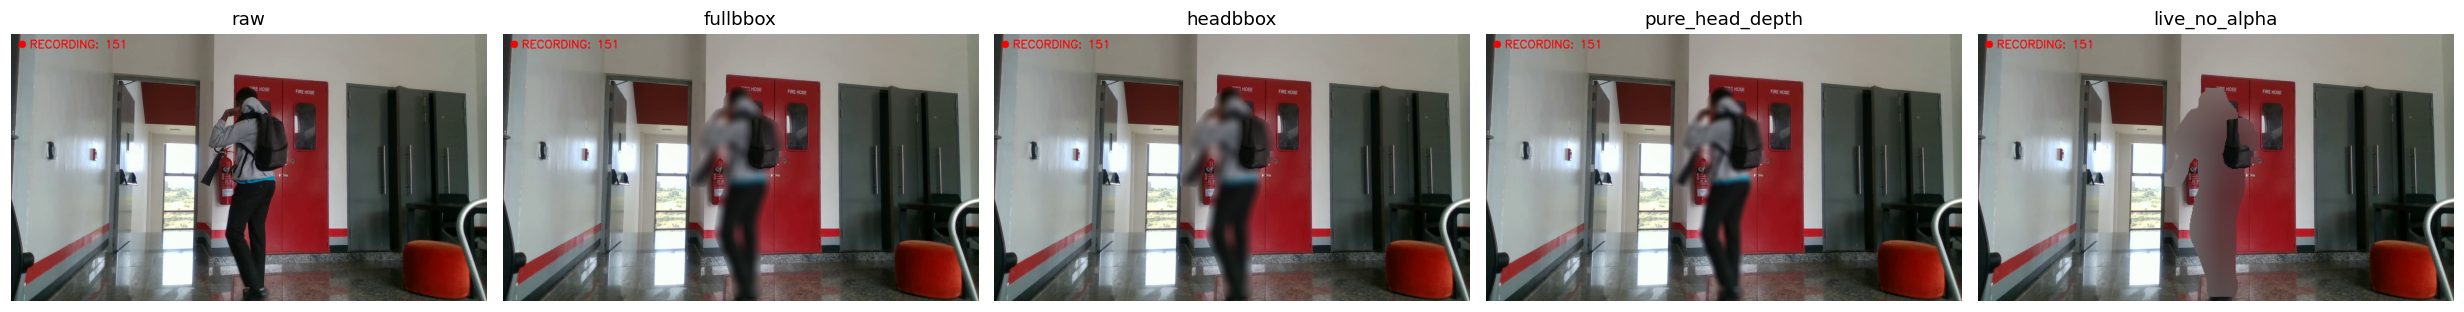

In [16]:
# CELL 4a · QUICK SANITY CHECK — one frame, all equations (blur mode)

cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), f"Cannot open: {VIDEO_PATH}"
cap.set(cv2.CAP_PROP_POS_FRAMES, 150)
ok, sample_frame = cap.read()
cap.release()
assert ok, "Could not read sample frame"

persons = detect_persons(sample_frame)
depth_map = estimate_depth(sample_frame)
H, W = sample_frame.shape[:2]
accessory_dets = _detect_accessories(sample_frame)

views = [(cv2.cvtColor(sample_frame.copy(), cv2.COLOR_BGR2RGB), "raw")]
for eq in EQUATIONS:
    _prs_buf.clear()
    anon = sample_frame.copy()
    for pid, (mask, box, _, head_box) in enumerate(persons):
        r_eval, disparity = compute_r_for_mode(box, head_box, eq, "blur", H, W, pid, depth_map=depth_map)
        redact_mask = get_redact_mask(sample_frame, mask, box, eq, H, W, accessory_dets=accessory_dets)
        anon = redact(anon, redact_mask, box, r_eval, "blur", disparity=disparity)
    views.append((cv2.cvtColor(anon, cv2.COLOR_BGR2RGB), eq))

fig, axes = plt.subplots(1, len(views), figsize=(4.5 * len(views), 5))
for ax, (img, title) in zip(axes, views):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(f"{OUT_DIR}/equation_sanity_blur.png", bbox_inches="tight")
plt.show()

### Cell 5b Summary
Run the offline alpha calibration engine to match blur budget across benchmark equations fairly.

In [17]:
# CELL 5b · OFFLINE ALPHA CALIBRATION ENGINE (run once per representative video)
# Goal: match the mean blur budget of baseline fullbbox(alpha=1.0)
# by solving alpha_head and alpha_d for:
#   headbbox        : max(alpha_head * log(5000 * A_head/A_img), 1)
#   pure_head_depth : max(alpha_d    * log1p(99 * disparity),     1)


def _collect_calibration_terms(video_path):
    cap = cv2.VideoCapture(video_path)
    assert cap.isOpened(), f"Cannot open: {video_path}"

    terms = {
        "fullbbox_base": [],
        "headbbox_base": [],
        "pure_head_depth_base": [],
    }

    fi = 0
    _last_dm = None
    while True:
        ok, fr = cap.read()
        if not ok:
            break

        H, W = fr.shape[:2]
        persons = detect_persons(fr)
        if fi % DEPTH_SAMPLE_EVERY == 0:
            _last_dm = estimate_depth(fr)
        depth_map = _last_dm

        if persons:
            mask, box, _, head_box = max(persons, key=lambda p: float(np.sum(p[0] > 0)))
            x1, y1, x2, y2 = [float(v) for v in box]
            hx1, hy1, hx2, hy2 = [float(v) for v in head_box]
            img_area = float(H * W)
            a_body = max((x2 - x1) * (y2 - y1), 1.0)
            a_head = max((hx2 - hx1) * (hy2 - hy1), 1.0)
            disparity = disparity_from_head(depth_map, head_box, H, W)

            terms["fullbbox_base"].append(np.log(100.0 * (a_body / img_area)))
            terms["headbbox_base"].append(np.log(5000.0 * (a_head / img_area)))
            terms["pure_head_depth_base"].append(np.log1p(99.0 * disparity))

        fi += 1
        if MAX_FRAMES is not None and fi >= MAX_FRAMES:
            break

    cap.release()
    return {k: np.array(v, dtype=float) for k, v in terms.items()}


def _mean_r(alpha, base_vals):
    if len(base_vals) == 0:
        return float("nan")
    return float(np.mean(np.maximum(alpha * base_vals, 1.0)))


def _solve_alpha_for_target(base_vals, target_mean_r, lo=0.0, hi=1.0, tol=1e-6, max_iter=80):
    if len(base_vals) == 0:
        return float("nan")

    lo_val = _mean_r(lo, base_vals)
    if target_mean_r <= lo_val + tol:
        return float(lo)

    hi_val = _mean_r(hi, base_vals)
    expand_iter = 0
    while hi_val < target_mean_r and expand_iter < 40:
        hi *= 2.0
        hi_val = _mean_r(hi, base_vals)
        expand_iter += 1

    if hi_val < target_mean_r:
        return float("nan")

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        mid_val = _mean_r(mid, base_vals)
        if abs(mid_val - target_mean_r) <= tol:
            return float(mid)
        if mid_val < target_mean_r:
            lo = mid
        else:
            hi = mid
    return float(0.5 * (lo + hi))


def calibrate_alphas(video_path):
    terms = _collect_calibration_terms(video_path)
    base_full = terms["fullbbox_base"]
    base_head = terms["headbbox_base"]
    base_depth = terms["pure_head_depth_base"]

    target_mean = _mean_r(1.0, base_full)
    alpha_head = _solve_alpha_for_target(base_head, target_mean)
    alpha_d = _solve_alpha_for_target(base_depth, target_mean)

    out = {
        "target_mean_r": float(target_mean),
        "alpha_fullbbox": 1.0,
        "alpha_headbbox": float(alpha_head),
        "alpha_pure_head_depth": float(alpha_d),
        "n_samples": int(len(base_full)),
    }
    return out



# ── CALIBRATION COMMENTED OUT: alphas are hardcoded in Cell 0 EVAL_ALPHA ──
# Re-run this cell only if you change the video or detection params.
# CALIBRATION = calibrate_alphas(VIDEO_PATH)
# CALIBRATED_EVAL_ALPHA = {
#     "fullbbox": 1.0,
#     "headbbox": float(CALIBRATION["alpha_headbbox"]),
#     "pure_head_depth": float(CALIBRATION["alpha_pure_head_depth"]),
# }
# EVAL_ALPHA.update(CALIBRATED_EVAL_ALPHA)
#
# print("=== OFFLINE CALIBRATION RESULT ===")
# print(f"video: {VIDEO_PATH}")
# print(f"samples: {CALIBRATION['n_samples']}")
# print(f"target mean r (fullbbox, alpha=1.0): {CALIBRATION['target_mean_r']:.6f}")
# print(f"alpha_headbbox: {CALIBRATION['alpha_headbbox']:.6f}")
# print(f"alpha_pure_head_depth: {CALIBRATION['alpha_pure_head_depth']:.6f}")
# print("\nApplied EVAL_ALPHA now active for later cells:")
# print(CALIBRATED_EVAL_ALPHA)
# print("\nEVAL_ALPHA variable updated to:")
# print(EVAL_ALPHA)
# print("\nSuggested dictionary to paste into Cell 0 if you want it permanent:")
# print("EVAL_ALPHA = {")
# print("    'fullbbox': 1.0,")
# print(f"    'headbbox': {CALIBRATION['alpha_headbbox']:.6f},")
# print(f"    'pure_head_depth': {CALIBRATION['alpha_pure_head_depth']:.6f},")
# print("}")

### Cell 5 Summary
Run one unified equation-by-mode sweep (including `live_no_alpha`) and compute all raw/anonymous benchmark metrics.

In [18]:
# CELL 5 · UNIFIED SWEEP — all equations, all modes

from collections import Counter

if "CALIBRATED_EVAL_ALPHA" in globals():
    EVAL_ALPHA.update(CALIBRATED_EVAL_ALPHA)
    print("Using calibrated alpha:", EVAL_ALPHA)
else:
    print("Calibration not found; using current EVAL_ALPHA:", EVAL_ALPHA)

# 1) Load frames + detections + cached depth maps once
cap = cv2.VideoCapture(VIDEO_PATH)
raw_frames, raw_persons, raw_depth_maps = [], [], []
fi = 0
_last_dm = None
while True:
    ok, fr = cap.read()
    if not ok:
        break
    raw_frames.append(fr)
    raw_persons.append(detect_persons(fr))
    if fi % DEPTH_SAMPLE_EVERY == 0:
        _last_dm = estimate_depth(fr)
    raw_depth_maps.append(_last_dm)
    fi += 1
    if MAX_FRAMES is not None and fi >= MAX_FRAMES:
        break
cap.release()
print(f"{VIDEO_PATH} -> {len(raw_frames)} frames")

# 2) R-history for alpha equations only (for smoothness plot)
R_HISTORY = {eq: [] for eq in EQUATIONS if eq != "live_no_alpha"}
for fr, persons, depth_map in zip(raw_frames, raw_persons, raw_depth_maps):
    H, W = fr.shape[:2]
    if persons:
        mask, box, _, head_box = max(persons, key=lambda p: float(np.sum(p[0] > 0)))
        for eq in R_HISTORY.keys():
            R_HISTORY[eq].append(compute_r_alpha_equation(box, head_box, eq, H, W, depth_map=depth_map, clamp=False))
    else:
        for eq in R_HISTORY.keys():
            R_HISTORY[eq].append(float("nan"))

# 3) Raw baseline metrics
raw_reid_embs, raw_kp, raw_actions, raw_dc = [], [], [], []
for fi, (fr, persons) in enumerate(zip(raw_frames, raw_persons)):
    if fi % SAMPLE_EVERY == 0:
        kv, action = pose_metrics(fr)
        raw_kp.append(kv)
        raw_actions.append(action)
        raw_dc.append(det_conf(fr))
    if fi % REID_EVERY == 0:
        for _, box, _, _ in persons:
            emb = reid_embedding(fr, box)
            if emb is not None:
                raw_reid_embs.append(emb)

raw_action_dist = dict(Counter(raw_actions))
raw_action_dist_actual = action_dist_without_none(raw_actions)
RAW = {
    "kp_vis": float(np.mean(raw_kp)) if raw_kp else 0.0,
    "det_conf": float(np.mean(raw_dc)) if raw_dc else 0.0,
    "top_action": Counter(raw_actions).most_common(1)[0][0] if raw_actions else "none",
    "action_dist": raw_action_dist,
    "action_dist_actual": raw_action_dist_actual,
}
print(f"Raw baseline: KP={RAW['kp_vis']:.3f}  DetConf={RAW['det_conf']:.3f}  top_action={RAW['top_action']}")

# 4) Unified equation x mode sweep
RESULTS = {}
for eq in EQUATIONS:
    for mode in MODES:
        _prs_buf.clear()
        anon_reid_embs, anon_kp, anon_actions, anon_dc = [], [], [], []

        for fi, (fr, persons, depth_map) in enumerate(zip(raw_frames, raw_persons, raw_depth_maps)):
            H, W = fr.shape[:2]
            anon = fr.copy()
            accessory_dets = _detect_accessories(fr)

            for pid, (mask, box, _, head_box) in enumerate(persons):
                r_eval, disparity = compute_r_for_mode(box, head_box, eq, mode, H, W, pid, depth_map=depth_map, smooth=True)
                redact_mask = get_redact_mask(fr, mask, box, eq, H, W, accessory_dets=accessory_dets)
                anon = redact(anon, redact_mask, box, r_eval, mode, disparity=disparity)

            # Redact orphan accessories (not merged into any person's mask)
            person_boxes = [b for _, b, _, _ in persons]
            for acc in accessory_dets:
                if any(_near_person(pb, acc['box'], H, W) for pb in person_boxes):
                    continue
                if acc.get('mask') is not None:
                    acc_mask = (acc['mask'] > 0).astype(np.uint8) * 255
                elif acc.get('poly') is not None:
                    acc_mask = _poly_mask(fr.shape, acc['poly'])
                else:
                    acc_mask = _box_mask(fr.shape, acc['box'])
                acc_mask = cv2.dilate(
                    acc_mask,
                    np.ones((ACCESSORY_DILATION_PX, ACCESSORY_DILATION_PX), np.uint8),
                    iterations=1,
                )
                anon = redact(anon, acc_mask, acc['box'], 1.0, mode, disparity=None)

            if fi % SAMPLE_EVERY == 0:
                kv, action = pose_metrics(anon)
                anon_kp.append(kv)
                anon_actions.append(action)
                anon_dc.append(det_conf(anon))

            if fi % REID_EVERY == 0:
                for _, box, _, _ in persons:
                    emb = reid_embedding(anon, box)
                    if emb is not None:
                        anon_reid_embs.append(emb)

        sim, r1 = reid_metrics(raw_reid_embs, anon_reid_embs)
        action_dist_all = dict(Counter(anon_actions))
        action_dist_actual = action_dist_without_none(anon_actions)
        top_action_actual = Counter(action_dist_actual).most_common(1)[0][0] if action_dist_actual else "none"

        RESULTS[(eq, mode)] = {
            "reid_sim": sim,
            "rank1": r1,
            "kp_vis": float(np.mean(anon_kp)) if anon_kp else 0.0,
            "det_conf": float(np.mean(anon_dc)) if anon_dc else 0.0,
            "top_action": Counter(anon_actions).most_common(1)[0][0] if anon_actions else "none",
            "top_action_actual": top_action_actual,
            "action_dist": action_dist_all,
            "action_dist_actual": action_dist_actual,
        }

        print(f"{eq:16s} + {mode:10s}  ReID={sim:.4f}  R1={r1:.4f}  KP={RESULTS[(eq, mode)]['kp_vis']:.4f}  top_actual={top_action_actual}")

print("\nUnified sweep complete.")

Calibration not found; using current EVAL_ALPHA: {'fullbbox': 1.0, 'headbbox': 0.484202, 'pure_head_depth': 0.335052}
PEViD-HD/validation_video_1.mp4 -> 647 frames
Raw baseline: KP=0.771  DetConf=0.738  top_action=grabbing
fullbbox         + blur        ReID=0.4066  R1=0.5085  KP=0.7286  top_actual=grabbing
fullbbox         + pixelate    ReID=0.2732  R1=0.0847  KP=0.4052  top_actual=grabbing
fullbbox         + blackout    ReID=0.3682  R1=0.3559  KP=0.6693  top_actual=grabbing
fullbbox         + depthzone   ReID=0.3478  R1=0.2542  KP=0.6129  top_actual=grabbing
headbbox         + blur        ReID=0.4129  R1=0.5254  KP=0.7337  top_actual=grabbing
headbbox         + pixelate    ReID=0.2810  R1=0.0847  KP=0.4549  top_actual=grabbing
headbbox         + blackout    ReID=0.3682  R1=0.3559  KP=0.6693  top_actual=grabbing
headbbox         + depthzone   ReID=0.3478  R1=0.2542  KP=0.6129  top_actual=grabbing
pure_head_depth  + blur        ReID=0.4220  R1=0.5932  KP=0.7342  top_actual=grabbing
pur

### Cell 6 Summary
Plot r-over-time trajectories and report per-equation standard deviation to compare temporal smoothness.

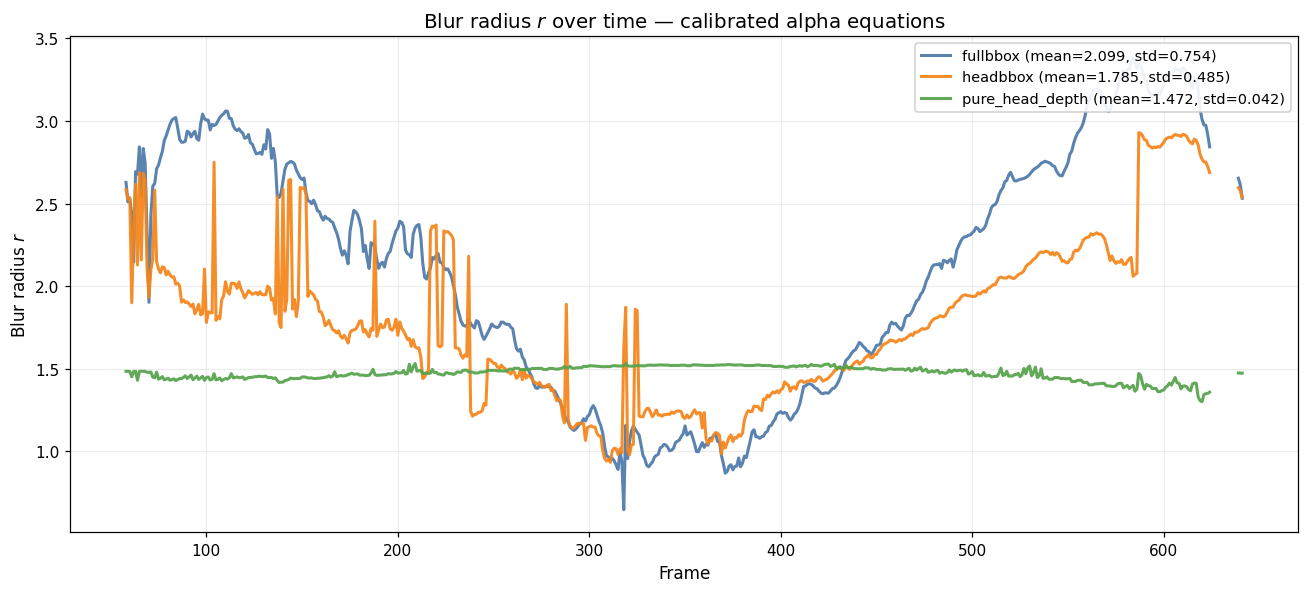

=== R-Trajectory Statistics (lower std = smoother) ===
fullbbox         mean=2.0995  std=0.7540
headbbox         mean=1.7853  std=0.4848
pure_head_depth  mean=1.4722  std=0.0419

Smoothness winner: pure_head_depth (std=0.0419)
Note: live_no_alpha is excluded here because this plot is for alpha-based equation smoothness.


In [19]:
# CELL 6 · R-VALUE PLOT — alpha equations only (live_no_alpha excluded)

EQ_COLORS = {
    "fullbbox": "#4C78A8",
    "headbbox": "#F58518",
    "pure_head_depth": "#54A24B",
}

frames = np.arange(len(raw_frames))
alpha_eqs = [eq for eq in EQUATIONS if eq in R_HISTORY]

fig, ax = plt.subplots(figsize=(12, 5.5))
stats_rows = []
for eq in alpha_eqs:
    arr = np.array(R_HISTORY[eq], dtype=float)
    valid = arr[~np.isnan(arr)]
    std_r = float(np.std(valid)) if len(valid) else float("nan")
    mu_r = float(np.mean(valid)) if len(valid) else float("nan")
    stats_rows.append((eq, mu_r, std_r))
    ax.plot(frames, arr, lw=2.0, color=EQ_COLORS[eq], alpha=0.92, label=f"{eq} (mean={mu_r:.3f}, std={std_r:.3f})")

ax.set_title("Blur radius $r$ over time — calibrated alpha equations", fontsize=13)
ax.set_xlabel("Frame", fontsize=11)
ax.set_ylabel("Blur radius $r$", fontsize=11)
ax.grid(alpha=0.22)
ax.legend(fontsize=9.5, frameon=True, framealpha=0.9, edgecolor="#cccccc", loc="upper right")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/r_history_calibrated.png", dpi=140, bbox_inches="tight")
plt.show()

smooth_winner = min(stats_rows, key=lambda t: t[2]) if stats_rows else None
print("=== R-Trajectory Statistics (lower std = smoother) ===")
for eq, mu, sd in stats_rows:
    print(f"{eq:16s} mean={mu:.4f}  std={sd:.4f}")
if smooth_winner is not None:
    print(f"\nSmoothness winner: {smooth_winner[0]} (std={smooth_winner[2]:.4f})")
print("Note: live_no_alpha is excluded here because this plot is for alpha-based equation smoothness.")

### Cell 6b Summary
Aggregate and visualize privacy metrics, then rank all method combinations by privacy score.

=== PRIVACY RANKING (exact values) ===
                      combo  reid_sim    rank1  det_conf  privacy_score
   live_no_alpha + pixelate  0.274442 0.016949  0.082761       0.875283
        headbbox + pixelate  0.280999 0.084746  0.034880       0.866458
        fullbbox + pixelate  0.273243 0.084746  0.043877       0.866045
 pure_head_depth + pixelate  0.319506 0.288136  0.026134       0.788741
       live_no_alpha + blur  0.282033 0.135593  0.279024       0.767783
pure_head_depth + depthzone  0.347843 0.254237  0.648928       0.582997
       headbbox + depthzone  0.347843 0.254237  0.648928       0.582997
       fullbbox + depthzone  0.347843 0.254237  0.648928       0.582997
  live_no_alpha + depthzone  0.347843 0.254237  0.648928       0.582997
 pure_head_depth + blackout  0.368184 0.355932  0.737605       0.512759
        fullbbox + blackout  0.368184 0.355932  0.737605       0.512759
        headbbox + blackout  0.368184 0.355932  0.737605       0.512759
   live_no_alpha + blacko

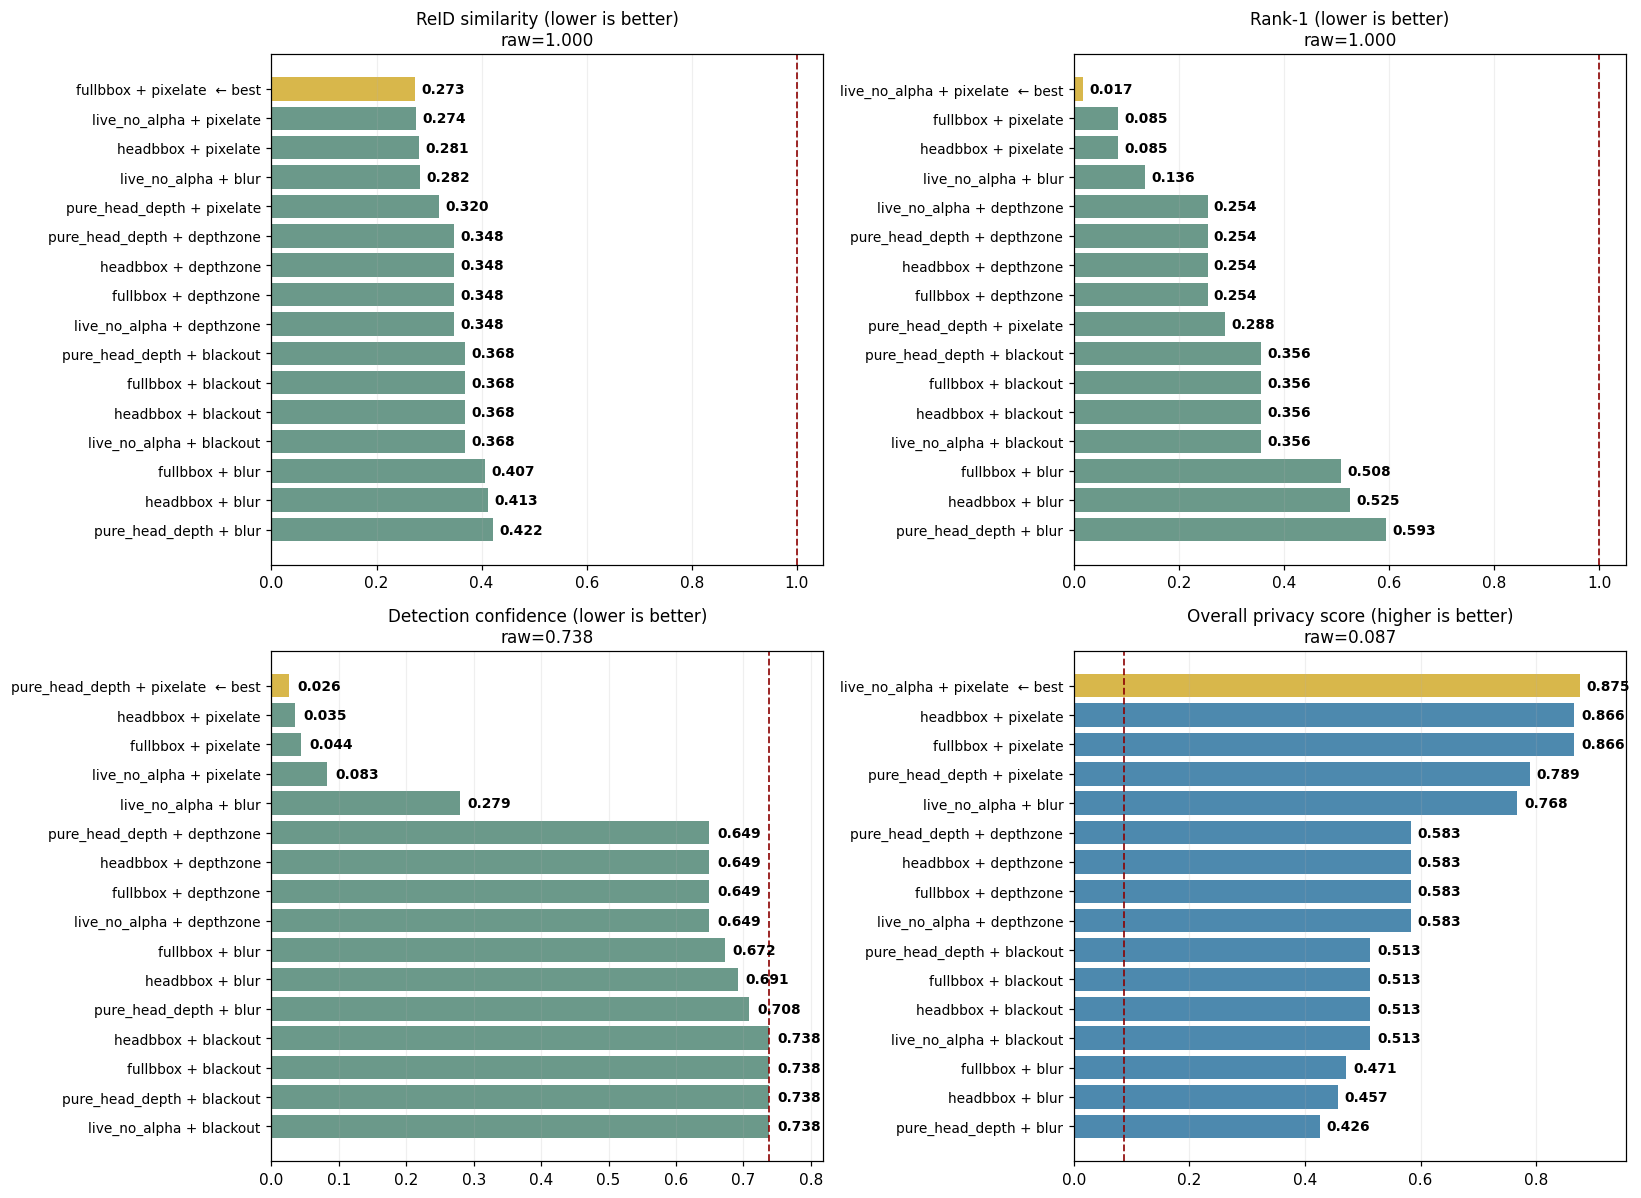


=== PRIVACY METRIC WINNERS ===
reid_sim: ['fullbbox + pixelate'] (value=0.273243)
rank1: ['live_no_alpha + pixelate'] (value=0.016949)
det_conf: ['pure_head_depth + pixelate'] (value=0.026134)
privacy_score: ['live_no_alpha + pixelate'] (value=0.875283)


In [20]:
# CELL 6b · PRIVACY RESULTS — winners highlighted + tie diagnostics

rows = [{"equation": eq, "mode": mode, **m} for (eq, mode), m in RESULTS.items()]
df = pd.DataFrame(rows)
df["combo"] = df["equation"] + " + " + df["mode"]
df["privacy_score"] = 1 - df[["reid_sim", "rank1", "det_conf"]].mean(axis=1)

RAW_PRIVACY_REF = {
    "reid_sim": 1.0,
    "rank1": 1.0,
    "det_conf": float(RAW.get("det_conf", np.nan)),
}
RAW_PRIVACY_REF["privacy_score"] = 1 - np.mean([RAW_PRIVACY_REF["reid_sim"], RAW_PRIVACY_REF["rank1"], RAW_PRIVACY_REF["det_conf"]])

print("=== PRIVACY RANKING (exact values) ===")
print(
    df[["combo", "reid_sim", "rank1", "det_conf", "privacy_score"]]
      .sort_values("privacy_score", ascending=False)
      .to_string(index=False, float_format=lambda x: f"{x:.6f}")
)

# Explain repeated numbers: check number of unique values before rounded display
for col in ["reid_sim", "rank1", "det_conf", "privacy_score"]:
    n_unique = df[col].nunique(dropna=True)
    print(f"{col}: unique exact values = {n_unique}")

metrics = [
    ("reid_sim", "ReID similarity (lower is better)", "lower"),
    ("rank1", "Rank-1 (lower is better)", "lower"),
    ("det_conf", "Detection confidence (lower is better)", "lower"),
    ("privacy_score", "Overall privacy score (higher is better)", "higher"),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()
winner_rows = []

for ax, (col, title, direction) in zip(axes, metrics):
    ranked = df.sort_values(col, ascending=(direction == "lower")).reset_index(drop=True)
    winner_val = ranked.iloc[0][col]
    is_winner = np.isclose(ranked[col].values, winner_val, atol=1e-9)
    colors = ["#D4AF37" if w else ("#3A7CA5" if col == "privacy_score" else "#5B8E7D") for w in is_winner]

    y = np.arange(len(ranked))
    ax.barh(y, ranked[col], color=colors, alpha=0.9)
    ax.set_yticks(y, ranked["combo"] + np.where(is_winner, "  ← best", ""))
    ax.tick_params(axis="y", labelsize=9)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.2)

    raw_val = RAW_PRIVACY_REF[col]
    if pd.notna(raw_val):
        ax.axvline(raw_val, color="darkred", ls="--", lw=1.2, alpha=0.9)
        subtitle = f"raw={raw_val:.3f}"
    else:
        subtitle = "raw=n/a"

    ax.set_title(f"{title}\n{subtitle}", fontsize=11, pad=6)
    xmax = max(float(ranked[col].max()), float(raw_val) if pd.notna(raw_val) else 0.0)
    ax.set_xlim(0, min(1.05, xmax + 0.08))
    for yi, val in zip(y, ranked[col]):
        ax.text(min(val + 0.012, 1.01), yi, f"{val:.3f}", va="center", fontsize=9, fontweight="bold")

    winners = ranked.loc[is_winner, "combo"].tolist()
    winner_rows.append((col, winners, winner_val))

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/privacy.png", bbox_inches="tight")
plt.show()

print("\n=== PRIVACY METRIC WINNERS ===")
for metric, winners, v in winner_rows:
    print(f"{metric}: {winners} (value={v:.6f})")

### Cell 7 Summary
Aggregate and visualize utility metrics, then rank all method combinations by utility score.

=== RAW ACTION BASELINE (excluding 'none') ===
raw actual-action count: 208 / 216 total action labels
raw top actual action: grabbing
raw actual-action profile: {'fighting': 0.10576923076923077, 'grabbing': 0.7884615384615384, 'dropping': 0.057692307692307696, 'walking': 0.04807692307692308}

=== UTILITY RANKING (exact values) ===
                      combo   kp_vis  action_presence_ratio  action_profile_match  raw_top_actual_match top_action_actual  utility_score
     pure_head_depth + blur 0.734205               1.000000              0.960940              0.813397          grabbing       0.859290
            headbbox + blur 0.733660               1.000000              0.956731              0.831731          grabbing       0.858176
            fullbbox + blur 0.728622               0.995192              0.971758              0.816425          grabbing       0.857220
        headbbox + blackout 0.669254               0.985577              0.916370              0.760976          grabbi

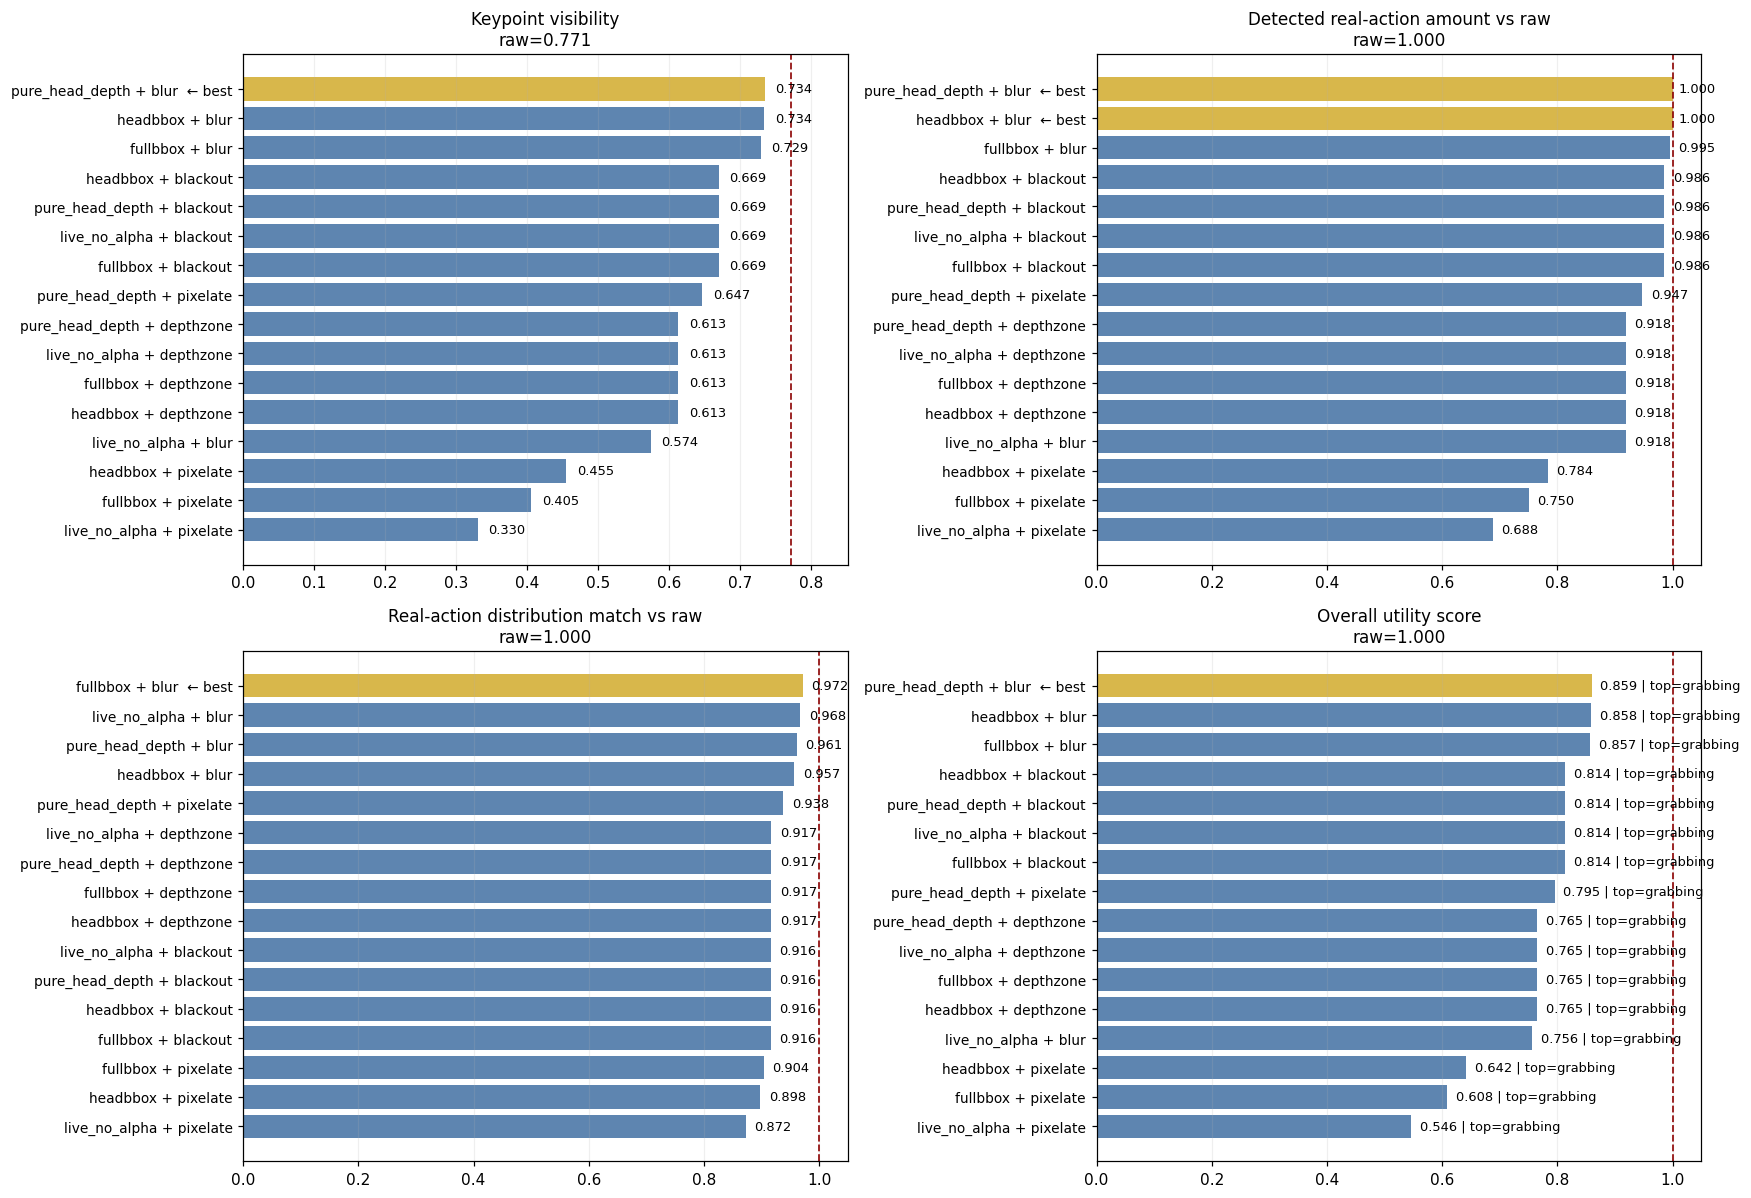


=== UTILITY METRIC WINNERS ===
kp_vis: ['pure_head_depth + blur'] (value=0.734205)
action_presence_ratio: ['pure_head_depth + blur', 'headbbox + blur'] (value=1.000000)
action_profile_match: ['fullbbox + blur'] (value=0.971758)
utility_score: ['pure_head_depth + blur'] (value=0.859290)


In [21]:
# CELL 7 · UTILITY RESULTS — excludes 'none' and compares real actions vs raw

ACTION_CLASSES = ["fighting", "grabbing", "dropping", "walking"]

def _to_action_profile(dist, classes):
    total = sum(dist.get(a, 0) for a in classes)
    if total <= 0:
        return {a: 0.0 for a in classes}
    return {a: dist.get(a, 0) / total for a in classes}

def _profile_overlap(p_raw, p_anon, classes):
    return float(sum(min(p_raw[a], p_anon[a]) for a in classes))

raw_dist_all = RAW["action_dist"]
raw_dist_actual = RAW.get("action_dist_actual", {})
raw_total_all = max(sum(raw_dist_all.values()), 1)
raw_total_actual = sum(raw_dist_actual.values())
raw_profile = _to_action_profile(raw_dist_actual, ACTION_CLASSES)
raw_top_actual = max(raw_dist_actual, key=raw_dist_actual.get) if raw_dist_actual else "none"

rows = []
for (eq, mode), m in RESULTS.items():
    dist_all = m["action_dist"]
    dist_actual = m.get("action_dist_actual", {})
    anon_total_all = max(sum(dist_all.values()), 1)
    anon_total_actual = sum(dist_actual.values())

    action_presence_ratio = float(anon_total_actual / max(raw_total_actual, 1))
    action_presence_ratio = min(action_presence_ratio, 1.0)
    anon_profile = _to_action_profile(dist_actual, ACTION_CLASSES)
    action_profile_match = _profile_overlap(raw_profile, anon_profile, ACTION_CLASSES)
    raw_top_actual_match = (dist_actual.get(raw_top_actual, 0) / max(anon_total_actual, 1)) if raw_top_actual != "none" else 0.0

    utility_score = 0.5 * m["kp_vis"] + 0.3 * action_presence_ratio + 0.2 * action_profile_match
    top_actual = max(dist_actual, key=dist_actual.get) if dist_actual else "none"

    rows.append({
        "equation": eq,
        "mode": mode,
        "combo": f"{eq} + {mode}",
        "kp_vis": float(m["kp_vis"]),
        "action_presence_ratio": action_presence_ratio,
        "action_profile_match": action_profile_match,
        "raw_top_actual_match": raw_top_actual_match,
        "top_action_actual": top_actual,
        "utility_score": utility_score,
    })

df_util = pd.DataFrame(rows).sort_values("utility_score", ascending=False).reset_index(drop=True)

RAW_UTILITY_REF = {
    "kp_vis": float(RAW["kp_vis"]),
    "action_presence_ratio": 1.0,
    "action_profile_match": 1.0,
}
RAW_UTILITY_REF["utility_score"] = 1.0

print("=== RAW ACTION BASELINE (excluding 'none') ===")
print(f"raw actual-action count: {raw_total_actual} / {raw_total_all} total action labels")
print(f"raw top actual action: {raw_top_actual}")
print(f"raw actual-action profile: {raw_profile}")

print("\n=== UTILITY RANKING (exact values) ===")
print(
    df_util[["combo", "kp_vis", "action_presence_ratio", "action_profile_match", "raw_top_actual_match", "top_action_actual", "utility_score"]]
      .to_string(index=False, float_format=lambda x: f"{x:.6f}")
)

metrics = [
    ("kp_vis", "Keypoint visibility", RAW_UTILITY_REF["kp_vis"]),
    ("action_presence_ratio", "Detected real-action amount vs raw", RAW_UTILITY_REF["action_presence_ratio"]),
    ("action_profile_match", "Real-action distribution match vs raw", RAW_UTILITY_REF["action_profile_match"]),
    ("utility_score", "Overall utility score", RAW_UTILITY_REF["utility_score"]),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()
utility_winners = []

for ax, (col, title, raw_val) in zip(axes, metrics):
    ranked = df_util.sort_values(col, ascending=False).reset_index(drop=True)
    winner_val = ranked.iloc[0][col]
    is_winner = np.isclose(ranked[col].values, winner_val, atol=1e-9)
    colors = ["#D4AF37" if w else "#4C78A8" for w in is_winner]

    y = np.arange(len(ranked))
    ax.barh(y, ranked[col], color=colors, alpha=0.9)
    ax.set_yticks(y, ranked["combo"] + np.where(is_winner, "  ← best", ""))
    ax.tick_params(axis="y", labelsize=9)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.2)
    ax.axvline(raw_val, color="darkred", ls="--", lw=1.2, alpha=0.9)
    ax.set_title(f"{title}\nraw={raw_val:.3f}", fontsize=11, pad=6)

    xmax = max(float(ranked[col].max()), float(raw_val))
    ax.set_xlim(0, min(1.05, xmax + 0.08))
    for yi, (_, row) in enumerate(ranked.iterrows()):
        label = f"{row[col]:.3f}"
        if col == "utility_score":
            label += f" | top={row['top_action_actual']}"
        ax.text(min(row[col] + 0.015, 1.01), yi, label, va="center", fontsize=8.5)

    winners = ranked.loc[is_winner, "combo"].tolist()
    utility_winners.append((col, winners, winner_val))

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/utility_summary.png", bbox_inches="tight")
plt.show()

print("\n=== UTILITY METRIC WINNERS ===")
for metric, winners, val in utility_winners:
    print(f"{metric}: {winners} (value={val:.6f})")

### Cell 8 Summary
Build the privacy-utility Pareto plot and export a ranked summary CSV of all combinations.

=== FINAL RANKING BY BALANCE (privacy + utility) ===
       equation      mode                       combo  reid_sim    rank1  det_conf  privacy_score  utility_score  balance top_action_actual
pure_head_depth  pixelate  pure_head_depth + pixelate  0.319506 0.288136  0.026134       0.788741       0.795072 0.791907          grabbing
  live_no_alpha      blur        live_no_alpha + blur  0.282033 0.135593  0.279024       0.767783       0.755887 0.761835          grabbing
       headbbox  pixelate         headbbox + pixelate  0.280999 0.084746  0.034880       0.866458       0.642138 0.754298          grabbing
       fullbbox  pixelate         fullbbox + pixelate  0.273243 0.084746  0.043877       0.866045       0.608384 0.737214          grabbing
  live_no_alpha  pixelate    live_no_alpha + pixelate  0.274442 0.016949  0.082761       0.875283       0.545826 0.710554          grabbing
pure_head_depth depthzone pure_head_depth + depthzone  0.347843 0.254237  0.648928       0.582997       0.7

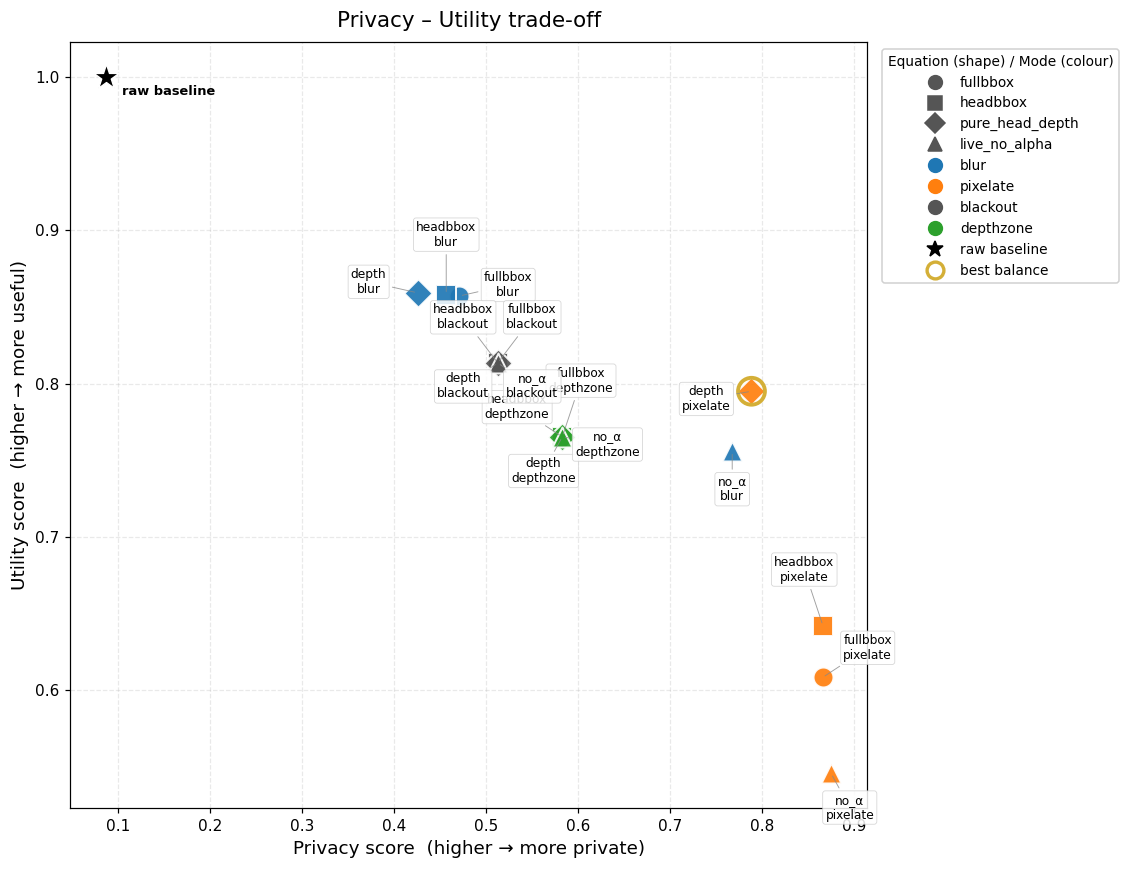

Saved: output/summary.csv


In [22]:
# CELL 8 · PRIVACY-UTILITY PARETO + FINAL SUMMARY

# Join privacy + utility tables by combo
df_priv = df[["equation", "mode", "combo", "reid_sim", "rank1", "det_conf", "privacy_score"]].copy()
df_pu = df_priv.merge(df_util[["combo", "utility_score", "top_action_actual"]], on="combo", how="left")
df_pu["balance"] = 0.5 * df_pu["privacy_score"] + 0.5 * df_pu["utility_score"]

MARKER = {"fullbbox": "o", "headbbox": "s", "pure_head_depth": "D", "live_no_alpha": "^"}
COLOR  = {"blur": "#1f77b4", "pixelate": "#ff7f0e", "blackout": "#555555",
          "depthzone": "#2ca02c", "depth_zone": "#2ca02c"}

EQ_ABBREV = {
    "fullbbox": "fullbbox",
    "headbbox": "headbbox",
    "pure_head_depth": "depth",
    "live_no_alpha": "no_α",
}

import importlib
_adjusttext_spec = importlib.util.find_spec("adjustText")
_HAS_ADJUST_TEXT = _adjusttext_spec is not None
if _HAS_ADJUST_TEXT:
    adjust_text = importlib.import_module("adjustText").adjust_text

fig, ax = plt.subplots(figsize=(13, 8))
df_pu_r = df_pu.reset_index(drop=True)

for _, row in df_pu_r.iterrows():
    mode_key = row["mode"] if row["mode"] in COLOR else "blur"
    ax.scatter(
        row["privacy_score"],
        row["utility_score"],
        marker=MARKER.get(row["equation"], "o"),
        color=COLOR[mode_key],
        s=170,
        linewidths=1.3,
        edgecolors="white",
        alpha=0.92,
        zorder=3,
    )

# Short two-line labels: equation abbrev + mode
texts = []
for i, row in df_pu_r.iterrows():
    x = float(row["privacy_score"])
    y = float(row["utility_score"])
    eq_short = EQ_ABBREV.get(row["equation"], row["equation"])
    label = eq_short + "\n" + str(row["mode"])

    if _HAS_ADJUST_TEXT:
        txt = ax.text(
            x, y, label,
            fontsize=8, zorder=7, ha="center", va="bottom",
            bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="#cccccc", lw=0.5, alpha=0.85),
        )
    else:
        # Angle-based evenly spaced offsets to minimise overlap
        import math
        angle = (i / len(df_pu_r)) * 2 * math.pi
        r_offset = 32
        dx = r_offset * math.cos(angle)
        dy = r_offset * math.sin(angle)
        txt = ax.annotate(
            label, (x, y),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=8, zorder=7, ha="center",
            bbox=dict(boxstyle="round,pad=0.22", fc="white", ec="#cccccc", lw=0.5, alpha=0.85),
            arrowprops=dict(arrowstyle="-", color="#888888", lw=0.6, alpha=0.8),
        )
    texts.append(txt)

if _HAS_ADJUST_TEXT and texts:
    adjust_text(
        texts, ax=ax,
        only_move={"points": "xy", "text": "xy"},
        expand_points=(1.4, 1.6),
        expand_text=(1.3, 1.5),
        force_points=0.5,
        force_text=0.6,
        arrowprops=dict(arrowstyle="-", color="#888888", lw=0.6, alpha=0.8),
    )

# Raw baseline star
ax.scatter(
    RAW_PRIVACY_REF["privacy_score"], 1.0,
    marker="*", color="black", s=300,
    edgecolors="white", linewidths=0.9, zorder=5,
)
ax.annotate(
    "raw baseline",
    (RAW_PRIVACY_REF["privacy_score"], 1.0),
    xytext=(10, -12), textcoords="offset points",
    fontsize=8.5, color="black", fontweight="bold",
)

# Best balance highlight ring
best_balance = df_pu["balance"].max()
best_rows = df_pu[np.isclose(df_pu["balance"], best_balance, atol=1e-9)]
for _, row in best_rows.iterrows():
    ax.scatter(
        row["privacy_score"], row["utility_score"],
        s=310, facecolors="none", edgecolors="#D4AF37", linewidths=2.5, zorder=6,
    )

ax.set_xlabel("Privacy score  (higher → more private)", fontsize=12)
ax.set_ylabel("Utility score  (higher → more useful)", fontsize=12)
ax.set_title("Privacy – Utility trade-off", fontsize=14, pad=10)
ax.tick_params(labelsize=10)
ax.grid(alpha=0.28, linestyle="--")

from matplotlib.lines import Line2D
# Equation shape legend
eq_handles = [
    Line2D([0], [0], marker=v, color="#555555", ms=9, ls="", label=k)
    for k, v in MARKER.items()
    if k in df_pu["equation"].unique()
]
# Mode colour legend
mode_handles = [
    Line2D([0], [0], marker="o", color=COLOR[k], ms=9, ls="", label=k)
    for k in COLOR
    if k in df_pu["mode"].unique()
]
# Special markers
special_handles = [
    Line2D([0], [0], marker="*", color="black", ms=11, ls="", label="raw baseline"),
    Line2D([0], [0], marker="o", markerfacecolor="none",
           markeredgecolor="#D4AF37", markeredgewidth=2.2, ms=11, ls="", label="best balance"),
]

leg = ax.legend(
    handles=eq_handles + mode_handles + special_handles,
    title="Equation (shape) / Mode (colour)",
    title_fontsize=9,
    fontsize=9,
    ncol=1,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
    framealpha=0.9,
    edgecolor="#cccccc",
)

summary = df_pu[[
    "equation", "mode", "combo",
    "reid_sim", "rank1", "det_conf",
    "privacy_score", "utility_score", "balance",
    "top_action_actual",
]].sort_values("balance", ascending=False).reset_index(drop=True)

print("=== FINAL RANKING BY BALANCE (privacy + utility) ===")
print(summary.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\nTop winner(s):")
for _, r in best_rows.iterrows():
    print(f"{r['combo']}  privacy={r['privacy_score']:.6f}  utility={r['utility_score']:.6f}  balance={r['balance']:.6f}")

print("\nLabel placement:", "adjustText" if _HAS_ADJUST_TEXT else "angle-offset fallback")

plt.tight_layout(rect=[0, 0, 0.80, 1])
plt.savefig(f"{OUT_DIR}/pareto.png", dpi=150, bbox_inches="tight")
plt.show()

summary.to_csv(f"{OUT_DIR}/summary.csv", index=False)
print(f"Saved: {OUT_DIR}/summary.csv")


### Cell 8 Result Summary
Review the privacy-utility Pareto frontier and final ranked leaderboard for this run.

## Multi-Video Analytics Pipeline

This section runs an active multi-video pipeline for the fixed video array, computes per-video and combined privacy-utility metrics, plots combined trade-off views, and exports anonymized videos for downstream training.

### Cell 11 Summary
Define and validate the fixed multi-video array used for batch analytics and exports.

In [23]:
# CELL 11 · MULTI-VIDEO CONFIG — fixed array for batch analytics + export

MULTI_OUT_DIR = f"{OUT_DIR}/multi_video"
Path(MULTI_OUT_DIR).mkdir(parents=True, exist_ok=True)

VIDEO_PATHS = [
    VIDEO_PATH,
    "PEViD-HD/stealing_day_indoor_3_1.mpg",
    "PEViD-HD/fighting_day_indoor_1_1.mpg",
    "PEViD-HD/walking_day_outdoor_1_1.mpg",
    "PEViD-HD/validation_video_1.mp4",
    "PEViD-HD/validation_video_2.mp4",
]
VIDEO_PATHS = [str(p) for p in dict.fromkeys(VIDEO_PATHS) if Path(p).exists()]
assert len(VIDEO_PATHS) >= 1, "No valid paths in VIDEO_PATHS"

print("Batch videos:")
for vp in VIDEO_PATHS:
    print(" -", vp)

Batch videos:
 - PEViD-HD/validation_video_1.mp4
 - PEViD-HD/stealing_day_indoor_3_1.mpg
 - PEViD-HD/fighting_day_indoor_1_1.mpg
 - PEViD-HD/walking_day_outdoor_1_1.mpg
 - PEViD-HD/validation_video_2.mp4


### Cell 12 Summary
Run the multi-video sweep with the current calibrated pipeline and build aggregated benchmark tables.

In [24]:
# CELL 12 · MULTI-VIDEO SWEEP — calibrated pipeline across VIDEO_PATHS

from collections import Counter

if "CALIBRATED_EVAL_ALPHA" in globals():
    EVAL_ALPHA.update(CALIBRATED_EVAL_ALPHA)
    print("Using calibrated alpha:", EVAL_ALPHA)
else:
    print("Calibration not found; using current EVAL_ALPHA:", EVAL_ALPHA)


def evaluate_video_metrics(video_path):
    cap = cv2.VideoCapture(video_path)
    assert cap.isOpened(), f"Cannot open: {video_path}"
    frames, persons_per_frame, depth_maps = [], [], []
    fi = 0
    _last_dm = None
    while True:
        ok, fr = cap.read()
        if not ok:
            break
        frames.append(fr)
        persons_per_frame.append(detect_persons(fr))
        if fi % DEPTH_SAMPLE_EVERY == 0:
            _last_dm = estimate_depth(fr)
        depth_maps.append(_last_dm)
        fi += 1
        if MAX_FRAMES is not None and fi >= MAX_FRAMES:
            break
    cap.release()

    raw_reid_embs, raw_kp, raw_actions, raw_dc = [], [], [], []
    for fi, (fr, persons) in enumerate(zip(frames, persons_per_frame)):
        if fi % SAMPLE_EVERY == 0:
            kv, action = pose_metrics(fr)
            raw_kp.append(kv)
            raw_actions.append(action)
            raw_dc.append(det_conf(fr))
        if fi % REID_EVERY == 0:
            for _, box, _, _ in persons:
                emb = reid_embedding(fr, box)
                if emb is not None:
                    raw_reid_embs.append(emb)

    raw_dist_all = dict(Counter(raw_actions))
    raw_dist_actual = action_dist_without_none(raw_actions)
    raw_top_actual = Counter(raw_dist_actual).most_common(1)[0][0] if raw_dist_actual else "none"
    raw_total_actual = max(sum(raw_dist_actual.values()), 1)

    raw_summary = {
        "kp_vis": float(np.mean(raw_kp)) if raw_kp else 0.0,
        "det_conf": float(np.mean(raw_dc)) if raw_dc else 0.0,
        "top_action": Counter(raw_actions).most_common(1)[0][0] if raw_actions else "none",
        "raw_top_actual": raw_top_actual,
        "raw_top_frac": float(raw_dist_actual.get(raw_top_actual, 0) / raw_total_actual) if raw_top_actual != "none" else 0.0,
        "reid_crops": len(raw_reid_embs),
    }

    results = {}
    for eq in EQUATIONS:
        for mode in ["blur", "pixelate", "blackout", "depthzone"]:
            _prs_buf.clear()
            anon_reid_embs, anon_kp, anon_actions, anon_dc = [], [], [], []

            for fi, (fr, persons, depth_map) in enumerate(zip(frames, persons_per_frame, depth_maps)):
                H, W = fr.shape[:2]
                anon = fr.copy()
                accessory_dets = _detect_accessories(fr)

                for pid, (mask, box, _, head_box) in enumerate(persons):
                    r_eval, disparity = compute_r_for_mode(box, head_box, eq, mode, H, W, pid, depth_map=depth_map, smooth=True)
                    redact_mask = get_redact_mask(fr, mask, box, eq, H, W, accessory_dets=accessory_dets)
                    anon = redact(anon, redact_mask, box, r_eval, mode, disparity=disparity)

                # Redact orphan accessories (not merged into any person's mask)
                person_boxes = [b for _, b, _, _ in persons]
                for acc in accessory_dets:
                    if any(_near_person(pb, acc['box'], H, W) for pb in person_boxes):
                        continue
                    if acc.get('mask') is not None:
                        acc_mask = (acc['mask'] > 0).astype(np.uint8) * 255
                    elif acc.get('poly') is not None:
                        acc_mask = _poly_mask(fr.shape, acc['poly'])
                    else:
                        acc_mask = _box_mask(fr.shape, acc['box'])
                    acc_mask = cv2.dilate(
                        acc_mask,
                        np.ones((ACCESSORY_DILATION_PX, ACCESSORY_DILATION_PX), np.uint8),
                        iterations=1,
                    )
                    anon = redact(anon, acc_mask, acc['box'], 1.0, mode, disparity=None)

                if fi % SAMPLE_EVERY == 0:
                    kv, action = pose_metrics(anon)
                    anon_kp.append(kv)
                    anon_actions.append(action)
                    anon_dc.append(det_conf(anon))

                if fi % REID_EVERY == 0:
                    for _, box, _, _ in persons:
                        emb = reid_embedding(anon, box)
                        if emb is not None:
                            anon_reid_embs.append(emb)

            sim, r1 = reid_metrics(raw_reid_embs, anon_reid_embs)
            anon_dist_actual = action_dist_without_none(anon_actions)
            anon_total_actual = max(sum(anon_dist_actual.values()), 1)
            raw_match = float(anon_dist_actual.get(raw_top_actual, 0) / anon_total_actual) if raw_top_actual != "none" else 0.0

            results[(eq, mode)] = {
                "reid_sim": sim,
                "rank1": r1,
                "kp_vis": float(np.mean(anon_kp)) if anon_kp else 0.0,
                "det_conf": float(np.mean(anon_dc)) if anon_dc else 0.0,
                "top_action": Counter(anon_actions).most_common(1)[0][0] if anon_actions else "none",
                "raw_action_match": raw_match,
            }

    return {
        "video": video_path,
        "n_frames": len(frames),
        "raw": raw_summary,
        "results": results,
    }


MULTI_VIDEO_RUNS = []
for vp in VIDEO_PATHS:
    run = evaluate_video_metrics(vp)
    MULTI_VIDEO_RUNS.append(run)
    print(f"{vp} -> {run['n_frames']} frames | raw KP={run['raw']['kp_vis']:.3f} raw Det={run['raw']['det_conf']:.3f} raw Action={run['raw']['top_action']}")

multi_rows = []
for run in MULTI_VIDEO_RUNS:
    for (eq, mode), m in run["results"].items():
        multi_rows.append({
            "video": run["video"],
            "equation": eq,
            "mode": mode,
            "combo": f"{eq} + {mode}",
            "reid_sim": m["reid_sim"],
            "rank1": m["rank1"],
            "det_conf": m["det_conf"],
            "kp_vis": m["kp_vis"],
            "raw_action_match": m["raw_action_match"],
            "top_action": m["top_action"],
            "privacy_score": 1 - np.mean([m["reid_sim"], m["rank1"], m["det_conf"]]),
            "utility_score": 0.6 * m["kp_vis"] + 0.4 * m["raw_action_match"],
        })
MULTI_VIDEO_RESULTS = pd.DataFrame(multi_rows)

MULTI_VIDEO_RAW = pd.DataFrame([
    {
        "video": run["video"],
        "kp_vis": run["raw"]["kp_vis"],
        "det_conf": run["raw"]["det_conf"],
        "raw_top_action": run["raw"]["top_action"],
        "raw_top_actual": run["raw"]["raw_top_actual"],
        "raw_top_frac": run["raw"]["raw_top_frac"],
        "reid_crops": run["raw"]["reid_crops"],
    }
    for run in MULTI_VIDEO_RUNS
])

MULTI_COMBINED = MULTI_VIDEO_RESULTS.groupby(["equation", "mode", "combo"], as_index=False).agg(
    video_count=("video", "nunique"),
    reid_sim_mean=("reid_sim", "mean"),
    reid_sim_std=("reid_sim", "std"),
    rank1_mean=("rank1", "mean"),
    rank1_std=("rank1", "std"),
    det_conf_mean=("det_conf", "mean"),
    det_conf_std=("det_conf", "std"),
    kp_vis_mean=("kp_vis", "mean"),
    kp_vis_std=("kp_vis", "std"),
    raw_action_match_mean=("raw_action_match", "mean"),
    raw_action_match_std=("raw_action_match", "std"),
    privacy_score_mean=("privacy_score", "mean"),
    privacy_score_std=("privacy_score", "std"),
    utility_score_mean=("utility_score", "mean"),
    utility_score_std=("utility_score", "std"),
)
for col in MULTI_COMBINED.columns:
    if col.endswith("_std"):
        MULTI_COMBINED[col] = MULTI_COMBINED[col].fillna(0.0)
MULTI_COMBINED["balance_mean"] = 0.5 * MULTI_COMBINED["privacy_score_mean"] + 0.5 * MULTI_COMBINED["utility_score_mean"]
MULTI_COMBINED = MULTI_COMBINED.sort_values("balance_mean", ascending=False).reset_index(drop=True)

print("\n=== MULTI-VIDEO RAW BASELINES ===")
print(MULTI_VIDEO_RAW.round(3).to_string(index=False))
print("\n=== MULTI-VIDEO COMBINED SUMMARY ===")
print(MULTI_COMBINED[[
    "combo", "video_count", "reid_sim_mean", "rank1_mean", "det_conf_mean",
    "kp_vis_mean", "raw_action_match_mean", "privacy_score_mean", "utility_score_mean", "balance_mean"
]].round(3).to_string(index=False))

MULTI_VIDEO_RESULTS.to_csv(f"{MULTI_OUT_DIR}/per_video_metrics.csv", index=False)
MULTI_VIDEO_RAW.to_csv(f"{MULTI_OUT_DIR}/raw_baselines.csv", index=False)
MULTI_COMBINED.to_csv(f"{MULTI_OUT_DIR}/combined_summary.csv", index=False)
print(f"\nSaved CSVs to {MULTI_OUT_DIR}")

Calibration not found; using current EVAL_ALPHA: {'fullbbox': 1.0, 'headbbox': 0.484202, 'pure_head_depth': 0.335052}
PEViD-HD/validation_video_1.mp4 -> 647 frames | raw KP=0.771 raw Det=0.738 raw Action=grabbing
PEViD-HD/stealing_day_indoor_3_1.mpg -> 400 frames | raw KP=0.870 raw Det=0.839 raw Action=grabbing
PEViD-HD/fighting_day_indoor_1_1.mpg -> 400 frames | raw KP=0.864 raw Det=0.702 raw Action=grabbing
PEViD-HD/walking_day_outdoor_1_1.mpg -> 400 frames | raw KP=0.615 raw Det=0.637 raw Action=grabbing
PEViD-HD/validation_video_2.mp4 -> 846 frames | raw KP=0.844 raw Det=0.899 raw Action=grabbing

=== MULTI-VIDEO RAW BASELINES ===
                               video  kp_vis  det_conf raw_top_action raw_top_actual  raw_top_frac  reid_crops
     PEViD-HD/validation_video_1.mp4   0.771     0.738       grabbing       grabbing         0.788          59
PEViD-HD/stealing_day_indoor_3_1.mpg   0.870     0.839       grabbing       grabbing         0.947          53
PEViD-HD/fighting_day_in

### Cell 13 Summary
Generate combined privacy/utility plots across the selected video array and report the best aggregate trade-off.

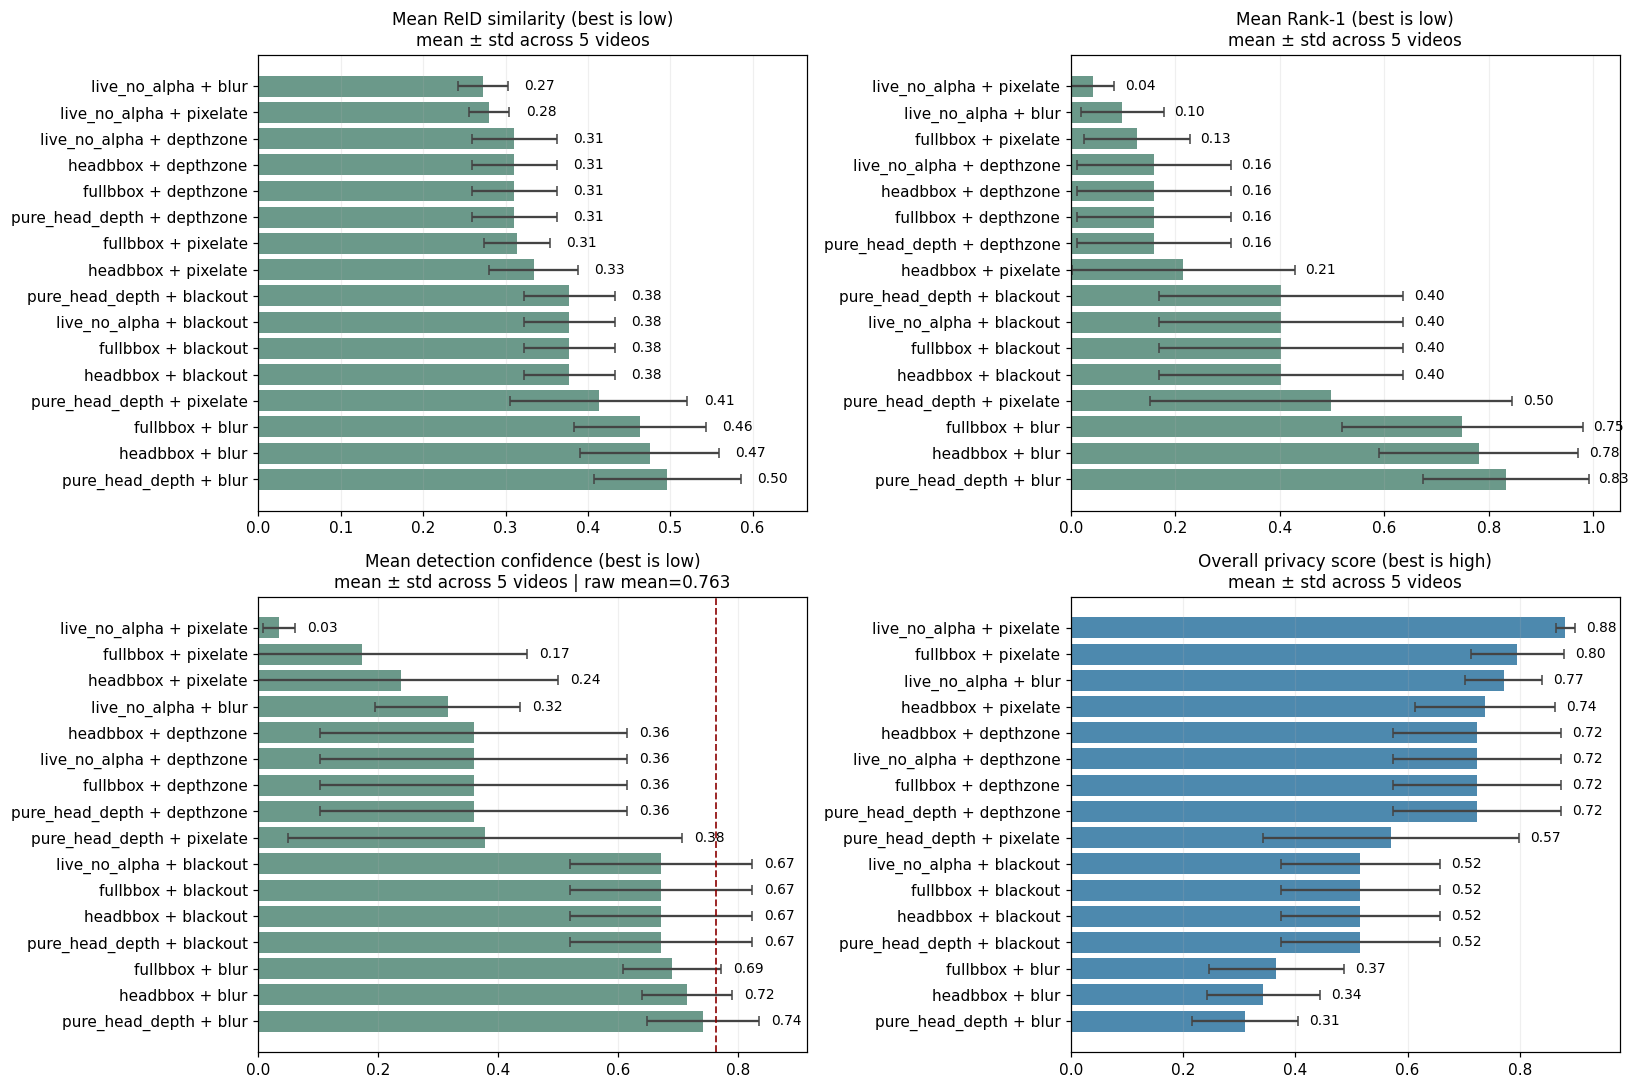

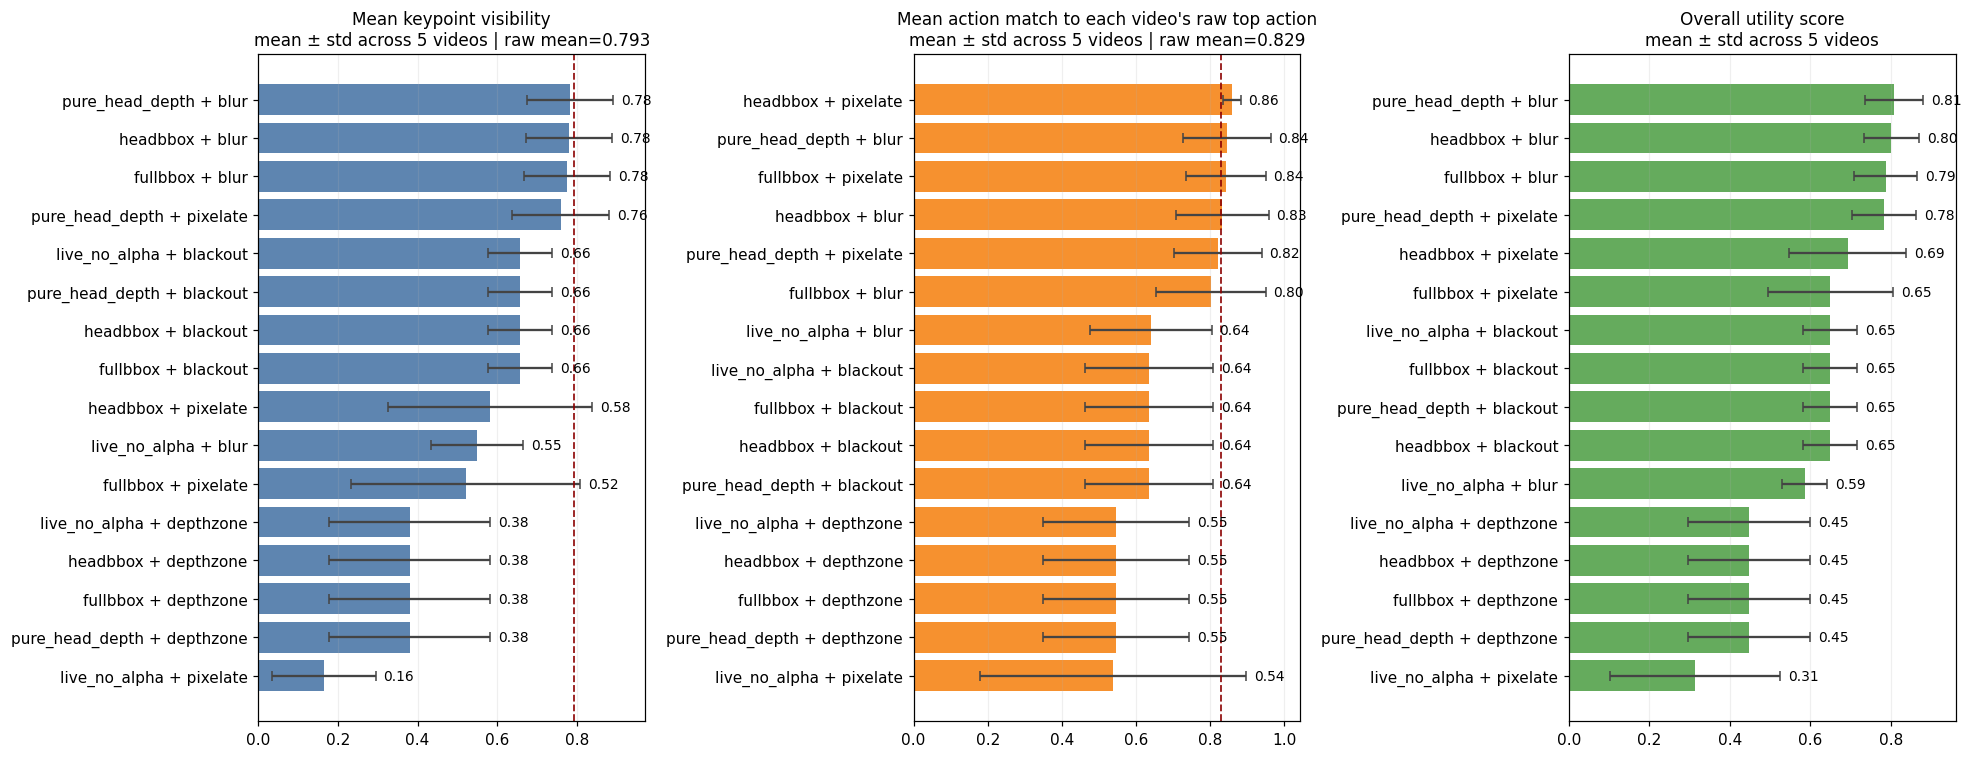

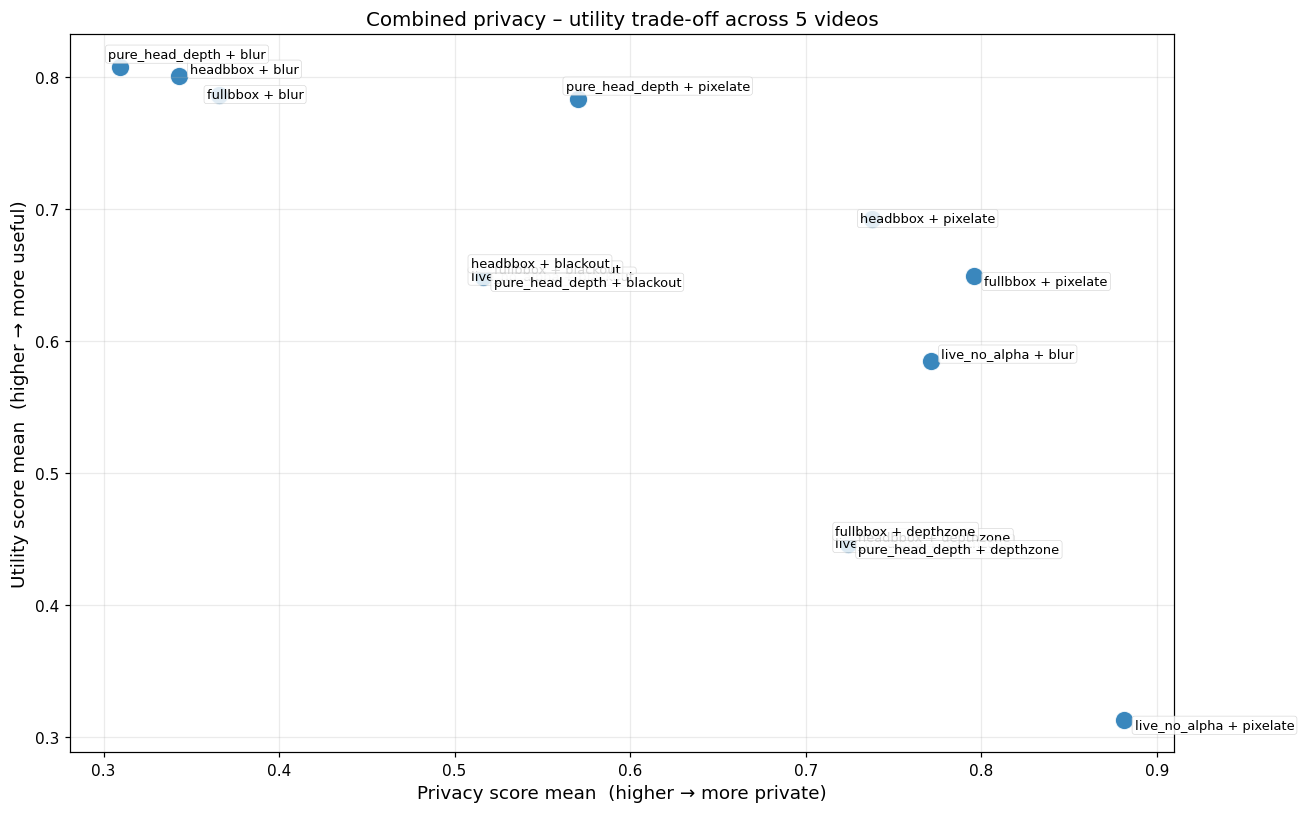


BEST COMBINED BALANCE:
fullbbox + pixelate | privacy=0.796 utility=0.650 balance=0.723


In [25]:
# CELL 13 · MULTI-VIDEO COMBINED PLOTS — aggregate privacy and utility across VIDEO_PATHS

raw_det_mean = float(MULTI_VIDEO_RAW["det_conf"].mean()) if len(MULTI_VIDEO_RAW) else np.nan
raw_kp_mean = float(MULTI_VIDEO_RAW["kp_vis"].mean()) if len(MULTI_VIDEO_RAW) else np.nan
raw_top_frac_mean = float(MULTI_VIDEO_RAW["raw_top_frac"].mean()) if len(MULTI_VIDEO_RAW) else np.nan

privacy_plots = [
    ("reid_sim_mean", "reid_sim_std", "Mean ReID similarity", "lower", np.nan, "#5B8E7D"),
    ("rank1_mean", "rank1_std", "Mean Rank-1", "lower", np.nan, "#5B8E7D"),
    ("det_conf_mean", "det_conf_std", "Mean detection confidence", "lower", raw_det_mean, "#5B8E7D"),
    ("privacy_score_mean", "privacy_score_std", "Overall privacy score", "higher", np.nan, "#3A7CA5"),
]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for ax, (col, err_col, title, direction, raw_val, color) in zip(axes, privacy_plots):
    ranked = MULTI_COMBINED.sort_values(col, ascending=(direction == "lower")).reset_index(drop=True)
    y = np.arange(len(ranked))
    ax.barh(y, ranked[col], xerr=ranked[err_col], color=color, alpha=0.9, ecolor="#444444", capsize=3)
    ax.set_yticks(y, ranked["combo"])
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.2)
    subtitle = f"mean ± std across {len(VIDEO_PATHS)} videos"
    if pd.notna(raw_val):
        ax.axvline(raw_val, color="darkred", ls="--", lw=1.2, alpha=0.9)
        subtitle += f" | raw mean={raw_val:.3f}"
    ax.set_title(f"{title} ({'best is low' if direction == 'lower' else 'best is high'})\n{subtitle}", fontsize=11)
    xmax = max(float((ranked[col] + ranked[err_col]).max()), float(raw_val) if pd.notna(raw_val) else 0.0)
    ax.set_xlim(0, min(1.05, xmax + 0.08))
    for yi, (_, row) in enumerate(ranked.iterrows()):
        ax.text(min(row[col] + row[err_col] + 0.02, 1.01), yi, f"{row[col]:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{MULTI_OUT_DIR}/combined_privacy.png", bbox_inches="tight")
plt.show()

utility_plots = [
    ("kp_vis_mean", "kp_vis_std", "Mean keypoint visibility", raw_kp_mean, "#4C78A8"),
    ("raw_action_match_mean", "raw_action_match_std", "Mean action match to each video's raw top action", raw_top_frac_mean, "#F58518"),
    ("utility_score_mean", "utility_score_std", "Overall utility score", np.nan, "#54A24B"),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, (col, err_col, title, raw_val, color) in zip(axes, utility_plots):
    ranked = MULTI_COMBINED.sort_values(col, ascending=False).reset_index(drop=True)
    y = np.arange(len(ranked))
    ax.barh(y, ranked[col], xerr=ranked[err_col], color=color, alpha=0.9, ecolor="#444444", capsize=3)
    ax.set_yticks(y, ranked["combo"])
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.2)
    subtitle = f"mean ± std across {len(VIDEO_PATHS)} videos"
    if pd.notna(raw_val):
        ax.axvline(raw_val, color="darkred", ls="--", lw=1.2, alpha=0.9)
        subtitle += f" | raw mean={raw_val:.3f}"
    ax.set_title(f"{title}\n{subtitle}", fontsize=11)
    xmax = max(float((ranked[col] + ranked[err_col]).max()), float(raw_val) if pd.notna(raw_val) else 0.0)
    ax.set_xlim(0, min(1.05, xmax + 0.08))
    for yi, (_, row) in enumerate(ranked.iterrows()):
        ax.text(min(row[col] + row[err_col] + 0.02, 1.01), yi, f"{row[col]:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{MULTI_OUT_DIR}/combined_utility.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(12, 7.5))
ax.scatter(MULTI_COMBINED["privacy_score_mean"], MULTI_COMBINED["utility_score_mean"], s=150, color="#1f77b4", alpha=0.88, edgecolors="white", linewidths=1.0)
for i, (_, row) in enumerate(MULTI_COMBINED.iterrows()):
    dx = 7 if (i % 2 == 0) else -8
    dy = -6 + (i % 4) * 4
    ax.annotate(
        row["combo"],
        (row["privacy_score_mean"], row["utility_score_mean"]),
        fontsize=8.5,
        xytext=(dx, dy),
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.20", fc="white", ec="#cccccc", lw=0.4, alpha=0.85),
    )
ax.set_xlabel("Privacy score mean  (higher → more private)", fontsize=12)
ax.set_ylabel("Utility score mean  (higher → more useful)", fontsize=12)
ax.set_title(f"Combined privacy – utility trade-off across {len(VIDEO_PATHS)} videos", fontsize=13)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{MULTI_OUT_DIR}/combined_tradeoff.png", bbox_inches="tight")
plt.show()

best = MULTI_COMBINED.iloc[0]
print("\nBEST COMBINED BALANCE:")
print(f"{best['combo']} | privacy={best['privacy_score_mean']:.3f} utility={best['utility_score_mean']:.3f} balance={best['balance_mean']:.3f}")

### Cell 14 Summary
Export anonymized videos for every video x equation x redaction mode using the active calibrated pipeline with no overlays.

In [15]:
# CELL 14 · VIDEO EXPORT — full redaction for the fixed export array
# Writes one MP4 per video x equation x mode.

import re

# ── overlay toggle ─────────────────────────────────────────────────────────────
# True  → burn bounding boxes + per-person scores onto each frame
# False → clean output (redaction only, no annotations)
EXPORT_OVERLAY = False

# Alphas are hardcoded in Cell 0; calibration cell is skipped.
print("Active EVAL_ALPHA:", EVAL_ALPHA)
print("Overlay enabled:", EXPORT_OVERLAY)

VIDEO_EXPORT_PATHS = [
    # VIDEO_PATH,
    # "PEViD-HD/droppingBag_day_indoor_1_1.mpg",
    # "PEViD-HD/droppingBag_day_indoor_1_2.mpg",
    # "PEViD-HD/droppingBag_night_indoor_1_1.mpg",
    # "PEViD-HD/validation_video_1.mp4",
    "PEViD-HD/validation_video_2.mp4",
]

# Deduplicate and filter to paths that actually exist, with explicit warnings.
seen = {}
for p in VIDEO_EXPORT_PATHS:
    p = str(p)
    if p in seen:
        continue
    seen[p] = Path(p).exists()

VIDEO_EXPORT_PATHS = [p for p, exists in seen.items() if exists]
for p, exists in seen.items():
    if not exists:
        print(f"  WARNING: skipping missing video: {p}")

assert VIDEO_EXPORT_PATHS, "No valid video paths found in VIDEO_EXPORT_PATHS"

# EXPORT_EQUATIONS = ["live_no_alpha", "fullbbox", "headbbox", "pure_head_depth"]
EXPORT_EQUATIONS = ["fullbbox", "pure_head_depth"]

# EXPORT_MODES     = ["blur", "pixelate", "blackout", "depthzone"]
EXPORT_MODES     = ["pixelate"]

EXPORT_ROOT = Path(OUT_DIR) / "exports"
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

def _safe_name(x):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(x)).strip("_")

# ── overlay helpers ────────────────────────────────────────────────────────────
_OV_FONT       = cv2.FONT_HERSHEY_SIMPLEX
_OV_FONT_SCALE = 0.48
_OV_THICKNESS  = 1
_OV_PAD        = 3

def _ov_text(img, text, x, y, txt_color, bg_color):
    """Draw text with a solid background rectangle for legibility."""
    (tw, th), bl = cv2.getTextSize(text, _OV_FONT, _OV_FONT_SCALE, _OV_THICKNESS)
    cv2.rectangle(img,
                  (x - _OV_PAD, y - th - _OV_PAD),
                  (x + tw + _OV_PAD, y + bl + _OV_PAD),
                  bg_color, -1)
    cv2.putText(img, text, (x, y), _OV_FONT, _OV_FONT_SCALE, txt_color, _OV_THICKNESS, cv2.LINE_AA)

def _draw_overlay(frame, persons, r_vals, disparities, eq, mode, frame_i):
    """
    Burn bounding boxes and per-person r/disparity scores onto frame.
    persons   : list of (mask, box, score, head_box)
    r_vals    : list of r_eval per person
    disparities: list of disparity per person
    """
    H, W = frame.shape[:2]

    # top-left corner: equation + mode label
    label = f"{eq} | {mode} | f{frame_i}"
    _ov_text(frame, label, 6, 18, (255, 255, 255), (30, 30, 30))

    for pid, ((mask, box, det_score, head_box), r, d) in enumerate(
        zip(persons, r_vals, disparities)
    ):
        x1, y1, x2, y2 = [int(v) for v in box]
        hx1, hy1, hx2, hy2 = [int(v) for v in head_box]

        # person bbox — blue
        cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 160, 60), 1)
        # head bbox — green
        cv2.rectangle(frame, (hx1, hy1), (hx2, hy2), (60, 220, 60), 1)

        # scores anchored just above the person box
        score_text = f"r={r:.2f}  d={d:.2f}"
        ty = max(y1 - 4, 16)
        _ov_text(frame, score_text, x1, ty, (255, 255, 255), (30, 30, 180))

    return frame

# ── export loop ────────────────────────────────────────────────────────────────
total = len(VIDEO_EXPORT_PATHS) * len(EXPORT_EQUATIONS) * len(EXPORT_MODES)
print(f"\nExporting {total} videos across {len(VIDEO_EXPORT_PATHS)} source video(s)...\n")

for vp in VIDEO_EXPORT_PATHS:
    vname = Path(vp).stem

    cap = cv2.VideoCapture(vp)
    assert cap.isOpened(), f"Cannot open: {vp}"

    fps  = cap.get(cv2.CAP_PROP_FPS) or 25.0
    W_v  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H_v  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    v_frames, v_persons, v_depth_maps = [], [], []
    fi = 0
    _last_dm = None
    while True:
        ok, fr = cap.read()
        if not ok:
            break
        v_frames.append(fr)
        v_persons.append(detect_persons(fr))
        if fi % DEPTH_SAMPLE_EVERY == 0:
            _last_dm = estimate_depth(fr)
        v_depth_maps.append(_last_dm)
        fi += 1
        if MAX_FRAMES is not None and fi >= MAX_FRAMES:
            break
    cap.release()

    if v_frames:
        H_v, W_v = v_frames[0].shape[:2]

    n_frames = len(v_frames)
    print(f"[{vname}] {n_frames} frames  {W_v}x{H_v}  @ {fps:.1f} fps")

    combo_count = len(EXPORT_EQUATIONS) * len(EXPORT_MODES)
    combo_done  = 0

    for eq in EXPORT_EQUATIONS:
        for mode in EXPORT_MODES:
            combo_done += 1
            suffix = "_overlay" if EXPORT_OVERLAY else ""
            out_path = EXPORT_ROOT / f"{_safe_name(vname)}_{eq}_{mode}{suffix}.mp4"
            writer = cv2.VideoWriter(
                str(out_path),
                cv2.VideoWriter_fourcc(*"mp4v"),
                fps,
                (W_v, H_v),
            )
            assert writer.isOpened(), f"VideoWriter failed to open: {out_path}"

            _prs_buf.clear()

            for frame_i, (fr, persons, depth_map) in enumerate(
                zip(v_frames, v_persons, v_depth_maps)
            ):
                H_f, W_f = fr.shape[:2]
                anon = fr.copy()

                frame_r_vals, frame_disparities = [], []

                accessory_dets = _detect_accessories(fr)
                for pid, (mask, box, _, head_box) in enumerate(persons):
                    r_eval, disparity = compute_r_for_mode(
                        box, head_box, eq, mode, H_f, W_f, pid,
                        depth_map=depth_map, smooth=True,
                    )
                    frame_r_vals.append(r_eval)
                    frame_disparities.append(disparity)
                    redact_mask = get_redact_mask(
                        fr, mask, box, eq, H_f, W_f, accessory_dets=accessory_dets
                    )
                    anon = redact(anon, redact_mask, box, r_eval, mode, disparity=disparity)

                # Redact orphan accessories.
                person_boxes = [b for _, b, _, _ in persons]
                for acc in accessory_dets:
                    if any(_near_person(pb, acc["box"], H_f, W_f) for pb in person_boxes):
                        continue
                    if acc.get("mask") is not None:
                        acc_mask = (acc["mask"] > 0).astype(np.uint8) * 255
                    elif acc.get("poly") is not None:
                        acc_mask = _poly_mask(fr.shape, acc["poly"])
                    else:
                        acc_mask = _box_mask(fr.shape, acc["box"])
                    acc_mask = cv2.dilate(
                        acc_mask,
                        np.ones((ACCESSORY_DILATION_PX, ACCESSORY_DILATION_PX), np.uint8),
                        iterations=1,
                    )
                    anon = redact(anon, acc_mask, acc["box"], 1.0, mode, disparity=None)

                if EXPORT_OVERLAY and persons:
                    anon = _draw_overlay(
                        anon, persons, frame_r_vals, frame_disparities,
                        eq, mode, frame_i,
                    )

                writer.write(anon)

                if (frame_i + 1) % 50 == 0 or (frame_i + 1) == n_frames:
                    print(
                        f"  [{combo_done}/{combo_count}] {eq}+{mode}  "
                        f"frame {frame_i+1}/{n_frames}",
                        end="\r",
                    )

            writer.release()
            print(
                f"  [{combo_done}/{combo_count}] {eq}+{mode}  "
                f"done → {out_path.relative_to(OUT_DIR)}          "
            )

    print()

print("All exports done.")


Active EVAL_ALPHA: {'fullbbox': 1.0, 'headbbox': 0.484202, 'pure_head_depth': 0.335052}
Overlay enabled: False

Exporting 2 videos across 1 source video(s)...

[validation_video_2] 846 frames  1280x720  @ 30.0 fps
  [1/2] fullbbox+pixelate  done → exports/validation_video_2_fullbbox_pixelate.mp4          
  [2/2] pure_head_depth+pixelate  done → exports/validation_video_2_pure_head_depth_pixelate.mp4          

All exports done.
